# TIB PCB Commissioning

Measure what **working** means for this assembled PCB: routes and connector identity, levels and losses,
calibrated range, noise, response, laser current granularity, and throughput behavior. Run each experiment
individually in the lab and chamber. This is an editable scientific notebook, not an automatic acceptance test.

New code lives here; `hispec_fibpcb.py` owns the command interface, collectors, and firmware-model evaluation.
The original [attenuator lab](attenuator_calibration_lab.ipynb), [throughput lab](throuput_monitor_lab.ipynb),
and [combined attenuation/throughput lab](atten_and_tput_cal_and_noise_lab.ipynb) remain intact. Electrical scope work is in
[tib_fvoa_noise_scope_lab.ipynb](tib_fvoa_noise_scope_lab.ipynb), which runs independently.

Use the workspace `.venv` kernel and run experiments individually. This edited lab copy retains your enabled
command cells: **Run All can operate hardware**. For offline review, execute the imports, table/analysis
definitions, reference tables, and selected replay cells only; no connection is needed. There is no prescribed total
runtime or guaranteed warmup time; keep transients and decide later which samples are stationary.

1. Configuration, inventory, board operation, dark
2. Physical routing and assembled static losses
3. Embedded autocalibration and combined fit figures
4. Adjacent current steps and independent fixed-current holds
5. Noise, response, throughput, and room/chamber/build comparisons

Firmware references: [commands](../doc/commands.md), [hardware](../doc/hardware.md),
[calibration](../doc/attenuator_calibration.md), [PD notes](../doc/photodiode_notes.md).


In [ ]:
from pathlib import Path
from dataclasses import asdict, is_dataclass, fields
from datetime import datetime, timezone
import math
import sys
import time
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy import signal
from IPython.display import display

TOOLS = next(p.resolve() for p in (Path.cwd(), Path.cwd() / 'tools', Path.cwd() / 'hispec-tib/tools')
             if (p / 'hispec_fibpcb.py').is_file())
if str(TOOLS) not in sys.path:
    sys.path.insert(0, str(TOOLS))
import hispec_fibpcb as hspcb

plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.18, 'figure.figsize': (11, 5)})

In [2]:
CHANNEL = 'yj'                         # Change to 'hk' for the other channel.
LASERS = {'yj': ['1028y', '1270j', '1430yj'], 'hk': ['1430hk', '1510h', '2330k']}[CHANNEL]
BROKER, DEVICE = 'hispec.caltech.edu', 'hsfib-tib'
OUTPUT, FIBER = f'{CHANNEL}_ao', 'M'    # Match the physical patch before each experiment.
CONDITION = 'room'                     # e.g. 'room', 'chamber_-5C'; measured temperatures are also saved.
BUILD_LABEL = 'atten1st autoleveling' # Built with attenuator first or laser first autoleveling used for bookkeeping, not code
STARTUP_HISTORY = 'enter cold bank / previously enabled / elapsed idle time'   #used for bookkeeping, not code
PATCH_NOTES = 'SW3 C FEI->5dB->FFLC MM Green (C); SW3 B AO->3dB->FFLC MM Yellow (B)' # used for bookkeeping, not code: enter actual fiber endpoints, jumpers, fixed attenuators, and meters'
FLASHED_ADC_SPS = 64                   # Flashed setup, not queried by the current API.
DETECTOR_BANDWIDTH_HZ = {'yj': 20.0, 'hk': 500.0}[CHANNEL]
ADC_INPUT_CAPACITANCE_UF = 0.47
CONNECT = True
pcb = globals().get('pcb')

DATA_DIR = TOOLS / 'commissioning_data'
CAPTURE_FILES = globals().get('CAPTURE_FILES', [])
CALIBRATION_FILES = globals().get('CALIBRATION_FILES', {})
ROUTE_FILES = globals().get('ROUTE_FILES', [])
LATEST_ROUTE_RUN_ID = globals().get('LATEST_ROUTE_RUN_ID')
ROUTE_SETTLE_S, ROUTE_MIN_STATIONARY_S = 1., 2.  # Shared by immediate review, replay, and route comparisons.
EXTERNAL_SETUP = PATCH_NOTES            # Initial default; edit the matching patches row for later captures.
EXTERNAL_LOSS_DB = np.nan               # Unknown is allowed; never silently treated as zero.
EXTERNAL_LOSS_BASIS = 'unknown'          # 'measured', 'estimated', or 'unknown'; retain the description above.


## Configuration and archives

Every new archive is a compressed NPZ with named arrays and scalar-column tables. `load_tables(path)` returns
DataFrames; `context` is a typed settings table (`key`, `kind`, `number`, `text`). Complete streamed samples, calibration
records, fits, bridge anchors, timestamps, temperatures, conditions, and errors are retained. No new JSON or
pickle payloads. The only JSON reader below opens existing calibration archives from the earlier lab.

The installed build is not inferred from the repository: enter its label above. Compare the actual flashed
attenuation-first and laser-first policies using those recorded labels. The owner-specified 64 SPS ADC, YJ 20 Hz detector, HK 500 Hz detector, and 0.47 µF ADC-input
capacitor are recorded as setup assumptions. Capacitance alone does not specify the analog cutoff.
Plots use the source/API vocabulary: **PD Net Signal** is `pd_net_mv`, **Throughput** is `tp`, and
calibration **Signal** is `signal_mv`. Tables use those names and documented window terms such as
`mean_net_mv` and `rms_mv`. Captions and Net summaries include the recorded `dark_mv`; missing context
stays unrecorded. The existing calibration is used throughout ordinary capture and replay.


## Measured laser-power references

These are the supplied **S154C** readings in µW at fractional laser command values 0.1, 0.5, and 1.0.
The sensor was reached through the laser's static attenuator and a measurement fiber of **unknown loss**.
The 25/50 dB values identify the attenuator parts; actual attenuation is wavelength dependent.
Reported ± values are retained without assuming standard deviation, error of the mean, or sensor accuracy.
In particular, 0.02308 ± 0.000013 µW is 23.08 nW ± 13 pW.

Edit these results directly; there is no meter-acquisition sequence here. The nominal diode comparison uses
[laser_properties.h](../app/src/laser_properties.h), copied below for independent offline analysis. It assumes
the default untuned current model, not a measurement of actual current. The apparent model-to-sensor attenuation
includes diode-model error, the static attenuator, and the measurement cable. It does not identify their losses
separately and is not a firmware property update. Route analysis uses exact measured levels only; another level
has no meter reference until one is entered. HK has no supplied meter readings.


In [3]:
# Compiled nominal comparison only; live captures retain their queried settings separately.
laser_nominal = pd.DataFrame([
    ('1028y', 1028.01, 14.5, 250., .185), ('1270j', 1270., 8., 60., .166),
    ('1430yj', 1430., 8., 60., .166), ('1430hk', 1430., 8., 60., .166),
    ('1510h', 1510., 8., 60., .166), ('2330k', 2329.81, 24.9, 120., .031)],
    columns=['laser', 'wavelength_nm', 'threshold_ma', 'nominal_ma', 'efficiency_mw_per_ma']).set_index('laser')
source_power_readings = pd.DataFrame([
    ('1028y', .1, 3.347, .078, 25.), ('1028y', .5, 17.87, .350, 25.), ('1028y', 1., 35.25, .855, 25.),
    ('1270j', .1, 1.469, .002, 25.), ('1270j', .5, 11.30, .0034, 25.), ('1270j', 1., 23.600, .0086, 25.),
    ('1430yj', .1, .02308, .000013, 50.), ('1430yj', .5, .07619, .000040, 50.),
    ('1430yj', 1., .1392, .000072, 50.)],
    columns=['laser', 'level', 'power_uw', 'reported_pm_uw', 'static_part_label_db'])
source_power_readings['sensor'] = 'S154C'
source_power_readings['reference_plane'] = 'sensor after static attenuator and measurement fiber'
source_power_readings['measurement_fiber_loss_db'] = np.nan
source_power_readings['uncertainty_kind'] = 'reported ±; statistical interpretation unspecified'
display(source_power_readings[['laser', 'level', 'power_uw', 'reported_pm_uw', 'static_part_label_db']])


,laser,level,power_uw,reported_pm_uw,static_part_label_db
0,1028y,0.1,3.34700,0.078000,25.0
1,1028y,0.5,17.87000,0.350000,25.0
2,1028y,1.0,35.25000,0.855000,25.0
3,1270j,0.1,1.46900,0.002000,25.0
4,1270j,0.5,11.30000,0.003400,25.0
5,1270j,1.0,23.60000,0.008600,25.0
6,1430yj,0.1,0.02308,0.000013,50.0
7,1430yj,0.5,0.07619,0.000040,50.0
8,1430yj,1.0,0.13920,0.000072,50.0


,laser,level,nominal_diode_uw,power_uw,apparent_combined_db
0,1028y,0.1,4356.75,3.34700,31.145069
1,1028y,0.5,21783.75,17.87000,30.860081
2,1028y,1.0,43567.50,35.25000,30.920035
3,1270j,0.1,863.20,1.46900,27.690896
4,1270j,0.5,4316.00,11.30000,25.820030
5,1270j,1.0,8632.00,23.60000,25.631994
6,1430yj,0.1,863.20,0.02308,45.728756
7,1430yj,0.5,4316.00,0.07619,47.531835
8,1430yj,1.0,8632.00,0.13920,47.924722


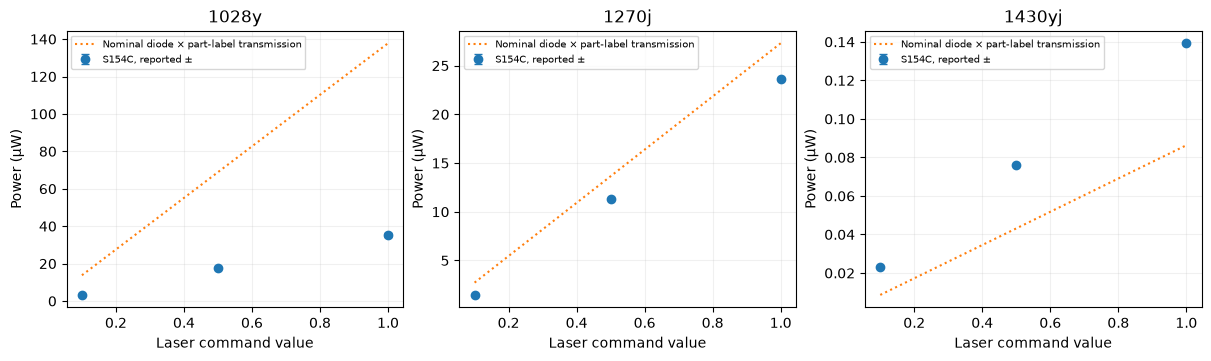

In [4]:
source_comparison = source_power_readings.merge(laser_nominal, left_on='laser', right_index=True)
source_comparison['nominal_diode_uw'] = (1000 * source_comparison.level *
    (source_comparison.nominal_ma-source_comparison.threshold_ma) * source_comparison.efficiency_mw_per_ma)
source_comparison['apparent_combined_db'] = 10*np.log10(source_comparison.nominal_diode_uw/source_comparison.power_uw)
display(source_comparison[['laser', 'level', 'nominal_diode_uw', 'power_uw', 'apparent_combined_db']])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), layout='constrained')
for ax, (name, group) in zip(axes, source_comparison.groupby('laser', sort=False)):
    ax.errorbar(group.level, group.power_uw, yerr=group.reported_pm_uw, fmt='o', capsize=3, label='S154C, reported ±')
    # This comparison deliberately uses the part label, not an inferred calibrated attenuation.
    ax.plot(group.level, group.nominal_diode_uw*10**(-group.static_part_label_db/10), ':',
            label='Nominal diode × part-label transmission')
    ax.set(title=name, xlabel='Laser command value', ylabel='Power (µW)')
    ax.legend(fontsize=7)
plt.show()


In [5]:
def parameter_table(values):
    """Flatten settings into a readable, typed table; no JSON or pickled objects."""
    rows = []
    def visit(key, value):
        if is_dataclass(value):
            value = asdict(value)
        if isinstance(value, dict):
            for name, item in value.items():
                visit(f'{key}.{name}' if key else str(name), item)
        elif isinstance(value, (tuple, list, np.ndarray)):
            for i, item in enumerate(value):
                visit(f'{key}.{i}', item)
        else:
            numeric = isinstance(value, (int, float, np.number)) and not isinstance(value, (bool, np.bool_))
            rows.append((key, 'number' if numeric else 'text', float(value) if numeric else np.nan,
                         '' if numeric or value is None else str(value)))
    visit('', values)
    return pd.DataFrame(rows, columns=['key', 'kind', 'number', 'text'])


def parameter(table, key, default=np.nan):
    """Read one saved scalar without reconstructing a driver object."""
    rows = table.loc[table.key.eq(key)]
    if rows.empty:
        return default
    row = rows.iloc[-1]
    return row.number if row.kind == 'number' else row.text if row.text != '' else default


def table_records(frame):
    """Keep numeric dtypes; encode text and stream flag tuples as Unicode for allow_pickle=False."""
    if not len(frame.columns):
        return np.empty(len(frame), dtype=[])
    frame = frame.copy()
    string_types = {}
    for name in frame:
        if frame[name].dtype.kind == 'O' or isinstance(frame[name].dtype, pd.StringDtype):
            frame[name] = frame[name].map(lambda v: '|'.join(v) if isinstance(v, tuple) else '' if v is None else str(v))
            string_types[name] = f'U{max(1, frame[name].str.len().max() if len(frame) else 1)}'
    return frame.to_records(index=False, column_dtypes=string_types)


def save_tables(stem, **tables):
    """Archive raw acquisition before analysis. Exclusive creation never overwrites a capture."""
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
    path = DATA_DIR / f'{stem}_{stamp}.npz'
    arrays = {name: table_records(value) if isinstance(value, pd.DataFrame) else np.asarray(value)
              for name, value in tables.items()}
    if any(a.dtype.hasobject for a in arrays.values()):
        raise TypeError('NPZ tables must have scalar numeric/Unicode columns, not Python objects.')
    with path.open('xb') as file:
        np.savez_compressed(file, **arrays)
    print(path)
    return path


def load_tables(path):
    """Offline read of this notebook's named arrays and structured tables."""
    with np.load(path, allow_pickle=False) as archive:
        return {key: pd.DataFrame.from_records(archive[key]) if archive[key].dtype.names is not None else archive[key].copy()
                for key in archive.files}


def snapshot(client, laser, *, output=None, fiber=None, switch_context='after setup'):
    """Query settings/context; no laser start or PD power-enabling read. Dark/external have no diode identity."""
    output, fiber = output or OUTPUT, fiber or FIBER
    values = dict(utc=datetime.now(timezone.utc).isoformat(), laser=laser, channel=CHANNEL,
        output=output, fiber=fiber, condition=CONDITION, build_label=BUILD_LABEL,
        startup_history=STARTUP_HISTORY, patch_notes=PATCH_NOTES, patch_id=f'{output}_to_{fiber}',
        external_setup=EXTERNAL_SETUP, external_loss_db=EXTERNAL_LOSS_DB, external_loss_basis=EXTERNAL_LOSS_BASIS,
        flashed_adc_sps=FLASHED_ADC_SPS, detector_bandwidth_hz=DETECTOR_BANDWIDTH_HZ,
        adc_input_capacitance_uf=ADC_INPUT_CAPACITANCE_UF,
        status=client.status(), clock=client.time(), heater=client.laser_bankheater(),
        bank=client.laser_bankpower(), pd_settings=client.pd_settings(CHANNEL),
        dark=client.pd_dark(CHANNEL), switches=client.mems(), switch_context=switch_context,
        return_loss=client.mems_route_loss(f'{CHANNEL}_{"mm" if fiber == "M" else "sm"}_to_{CHANNEL}_pd'))
    if 'patches' in globals() and values['patch_id'] in patches.index:
        patch = patches.loc[values['patch_id']]
        values.update(external_setup=patch.external_setup, external_loss_db=patch.external_loss_db,
                      external_loss_basis=patch.external_loss_basis)
    if laser in hspcb.LASER_NAMES:
        source = f'{CHANNEL}_1430' if laser.startswith('1430') else f'{CHANNEL}_laser'
        values.update(laser_status=client.laser(laser), engineering=client.laser_status(laser),
            laser_settings=client.laser_settings(laser), coeff=client.atten_coeff(laser), atten=client.atten(laser))
        if output in (f'{CHANNEL}_ao', f'{CHANNEL}_fei'):
            values['launch_loss'] = client.mems_route_loss(f'{source}_to_{output}')
    return parameter_table(values)


def read_route_losses(client, routes):
    """Query current effective losses. The wire value is fraction LOST, not transmission or dB."""
    rows = []
    for route in routes:
        for item in client.mems_route_loss(route).lasers:
            if item.name in LASERS:
                tx = 1.0-float(item.value)
                rows.append(dict(route=route, laser=item.name, transmission=tx,
                    loss_db=-10*np.log10(tx) if tx > 0 else np.nan))
    return pd.DataFrame(rows, columns=['route', 'laser', 'transmission', 'loss_db'])


In [ ]:
def launch_components(laser, output):
    """Ordered nominal components, with canonical control states or passive ports. No commands.

    YJ combiner inputs follow the owner's schematic. HK input numbers remain unrecorded.
    Only 1430 traverses forward_retro. This describes topology, not verified connectivity.
    AO/FEI and retro launch fibers are included in their switch/splitter measurements.
    """
    channel, _, endpoint = str(output).partition('_')
    if laser not in (*hspcb.LASER_NAMES, 'external') or endpoint not in ('ao', 'fei', 'retro_1', 'retro_2', 'retro_3', 'retro_4'):
        return []
    parts = [(f'static_atten_{laser}', ''), (f'FVOA1_{laser}', ''), (f'FVOA2_{laser}', '')]
    if endpoint.startswith('retro_'):
        return parts + [(f'{channel}_forward_retro', 'B'), (f'{channel}_spl', f'output {endpoint[-1]}')] if laser == f'1430{channel}' else []
    if laser == 'external':
        parts = [(f'{channel}_cal_input_fiber', '')]
    else:
        if laser.startswith('1430'):
            parts += [(f'{channel}_forward_retro', 'A')]
        port = {'1028y': '1', '1270j': '2', '1430yj': '3'}.get(laser, 'unrecorded')
        parts += [(f'{channel}_wdm1', f'input {port}')]
    return parts + [(f'{channel}_laser_cal', 'B' if laser == 'external' else 'A'),
                    (f'{channel}_ao_fei', 'A' if endpoint == 'ao' else 'B')]


def capture_details(context, samples=None, *, experiment='capture'):
    """Readable capture identity from its archive, never from today's PCB/configuration.

    Reported states are software intent, not optical position measurements. Historical
    pre-setup snapshots cannot establish the states used during calibration or throughput.
    """
    laser = 'none' if experiment == 'dark' else str(parameter(context, 'laser', 'unspecified'))
    output = str(parameter(context, 'output', 'unrecorded'))
    channel = str(parameter(context, 'channel', output.split('_')[0]))
    fiber = str(parameter(context, 'fiber', 'unrecorded'))
    states = {}
    for key in context.loc[context.key.str.startswith('switches.') & context.key.str.endswith('.name'), 'key']:
        name = str(parameter(context, key, ''))
        if name.startswith(channel+'_'):
            states[name] = str(parameter(context, key[:-4]+'state', '?'))
    recorded_experiment = str(samples.experiment.iloc[0]) if samples is not None and not samples.empty and 'experiment' in samples else experiment
    settings_vary = recorded_experiment in ('autocalibration', 'throughput', 'throughput_live')
    scope = parameter(context, 'switch_context', '')
    if not scope:
        scope = ('legacy context; not verified after routing' if settings_vary
                 else 'archived readback; timing unrecorded') if states else 'not recorded'
    parts = launch_components(laser, output)
    launch = ' → '.join([laser] + [f'{name}={port}' if port in ('A', 'B') else f'{name} ({port})' if port else name
                                 for name, port in parts]) if parts else 'no bank source' if laser == 'none' else 'unrecorded'
    selected_return = f'{channel}_{"mm" if fiber == "M" else "sm"}_to_{channel}_pd' if fiber in ('M', 'S') else 'unrecorded'
    purpose = str(parameter(context, 'route_step.purpose', ''))
    step, repeat = parameter(context, 'route_step.step'), parameter(context, 'repeat')
    if samples is not None and not samples.empty:
        # Older route archives have selection/repeat, but no group identifier: never infer a group from repeat=0.
        if not purpose and 'selection' in samples:
            purpose = {'intended': 'Baseline', 'alternate_return': 'Return selection check',
                       'alternate_launch': 'Launch selection check', 'restored': 'Restored baseline'}.get(str(samples.selection.iloc[0]), '')
        if not np.isfinite(repeat) and 'repeat' in samples:
            repeat = float(samples.repeat.iloc[0])+1  # Old repeats were zero-based.
    requested = ' · '.join(f'{name}={parameter(context, "route_step."+name)}' for name in states
                          if parameter(context, 'route_step.'+name, '') in ('A', 'B'))
    return dict(laser=laser, run_id=str(parameter(context, 'run_id', '')), step=step, repeat=repeat, purpose=purpose,
        selected_output=output, selected_fiber=fiber, nominal_launch=launch, selected_return=selected_return,
        patch_id=str(parameter(context, 'patch_id', 'unrecorded')),
        reported_switches=' · '.join(f'{name}={state}' for name, state in states.items()) or 'not recorded',
        **{f'{channel}_{role}': states.get(f'{channel}_{role}', '?')
           for role in ('forward_retro', 'laser_cal', 'ao_fei', 'mm_sm')},
        requested_switches=requested, switch_context=scope, settings_vary=settings_vary,
        source_level=parameter(context, 'route_test.level', parameter(context, 'laser_status.value')),
        current_ma=parameter(context, 'engineering.i_mA'), dark_mv=parameter(context, 'dark.dark.mean_mv'),
        dac1_mv=parameter(context, 'atten.v1_mv'), dac2_mv=parameter(context, 'atten.v2_mv'))


def capture_title(context, experiment, samples=None):
    """Shared figure caption: route identity, reported settings and explicitly labeled bookkeeping."""
    d = capture_details(context, samples, experiment=experiment)
    setting = []
    for key, label, unit in [('source_level', 'level', ''), ('current_ma', 'current', ' mA'),
                             ('dac1_mv', 'FVOA1 DAC', ' mV'), ('dac2_mv', 'FVOA2 DAC', ' mV')]:
        if np.isfinite(d[key]):
            setting.append(f'{label}: {d[key]:g}{unit}')
    # Calibration and autolevel vary the drives; a single snapshot is not the sweep's setting.
    if d['settings_vary']:
        setting = ['Current and DAC settings vary during acquisition']
    setting.append(f'dark_mv: {d["dark_mv"]:g} mV' if np.isfinite(d['dark_mv']) else 'dark_mv: unrecorded')
    lines = [f'{experiment} · {d["laser"]}'+(f' · {d["purpose"]}' if d['purpose'] else '')+(f' · repeat {d["repeat"]:g}' if np.isfinite(d['repeat']) else ''),
        ' | '.join(setting), f'Reported switches ({d["switch_context"]}): {d["reported_switches"]}',
        'Nominal launch: '+d['nominal_launch'],
        f'Return selected: {d["selected_return"]} | Physical patch: {d["patch_id"]}',
        f'Condition: {parameter(context, "condition", "unrecorded")} | Build: {parameter(context, "build_label", "unrecorded")}']
    return '\n'.join(textwrap.fill(line, width=145, break_long_words=False, break_on_hyphens=False) for line in lines if line)


In [7]:
def stationary_segments(frame, settle_s=1.0, minimum_s=2.0):
    """Keep separate contiguous fixed-setting intervals; do not close gaps by dropping bad rows."""
    if len(frame) < 3:
        return []
    frame = frame.reset_index(drop=True)
    dt = frame.t_ms.diff()/1000
    nominal = dt[dt > 0].median()
    valid = np.isfinite(frame.pd_net_mv) & np.isfinite(frame.pd_mv) & frame.pd_mv.lt(hspcb.PD_ADC_USABLE_MV)
    valid &= ~frame.autolevel.astype(bool)
    boundary = (dt <= 0) | (dt > 1.5*nominal) | ~valid | ~valid.shift(fill_value=False)
    for column in ('channel', 'laser', 'experiment', 'point', 'repeat', 'step', 'step_index', 'selection'):
        if column in frame:
            labels = frame[column].astype('string').fillna('')
            boundary |= labels.ne(labels.shift(fill_value=''))
    # 0.1 mA steps are the experiment: never merge them using the old 0.2 mA tolerance.
    for column, tolerance in (('laser_current_ma', .049), ('atten_db', .005)):
        boundary |= frame[column].diff().abs().gt(tolerance)
    parts = []
    for _, group in frame.groupby(boundary.cumsum(), sort=False):
        if not valid.loc[group.index].all():
            continue
        group = group.loc[(group.t_ms-group.t_ms.iloc[0])/1000 >= settle_s]
        if len(group) >= 3 and (group.t_ms.iloc[-1]-group.t_ms.iloc[0])/1000 >= minimum_s:
            parts.append(group.reset_index(drop=True))
    return parts


def noise_statistics(part):
    """Empirical scatter, drift, spectrum, ACF and averaging; shared calibration errors are separate."""
    y = part.pd_net_mv.to_numpy(float)
    t = (part.t_ms.to_numpy(float)-float(part.t_ms.iloc[0]))/1000
    dt, rms = np.diff(t), np.std(y, ddof=1)
    fs = 1/np.median(dt)
    centered = y-y.mean()
    acf = signal.correlate(centered, centered, mode='full', method='fft')[len(y)-1:]/np.arange(len(y), 0, -1)
    acf = acf/acf[0] if acf[0] > 0 else np.full_like(acf, np.nan)
    f, psd = signal.welch(y, fs=fs, nperseg=min(1024, max(3, len(y)//4)), detrend='constant')
    blocks = []
    for count in np.unique(np.maximum(1, np.round(np.array([.05,.1,.25,.5,1,2,5,10,20,30,60])*fs).astype(int))):
        n = len(y)//count
        if n < 4:
            continue
        means = y[:n*count].reshape(n, count).mean(axis=1)
        blocks.append(dict(tau_s=count/fs, blocks=n, rms_mean_mv=np.std(means, ddof=1),
            iid_rms_mean_mv=rms/np.sqrt(count), allan_mv=np.sqrt(.5*np.mean(np.diff(means)**2)),
            adjacent_block_corr=np.corrcoef(means[:-1], means[1:])[0,1] if np.std(means)>0 else np.nan))
    metrics = dict(samples=len(y), duration_s=t[-1], mean_mv=y.mean(), rms_mv=rms,
        detrended_rms_mv=np.std(signal.detrend(y), ddof=1), drift_mv_per_s=np.polyfit(t, y, 1)[0],
        relative_rms=rms/abs(y.mean()) if abs(y.mean()) > 3*rms else np.nan,
        adjacent_corr=acf[1], sample_hz=fs, max_gap_ms=1000*max(dt), timing_jitter_ms=1000*np.std(dt))
    return metrics, pd.DataFrame(dict(f_hz=f, psd_mv2_per_hz=psd)), pd.DataFrame(blocks), acf


In [ ]:
def review_capture(path, *, settle_s=None, minimum_s=None, show=True, detailed=False, dark_diagnostics=False):
    """Offline Net trace/statistics shared by acquisition and replay; no commands or writes.

    dark_diagnostics explicitly adds the input reading and configured dark reference for validity checks.
    Complete streamed records and diagnostic statistics remain available regardless of display choice.
    """
    saved = load_tables(path)
    data, context = saved.get('samples', pd.DataFrame()), saved.get('context', parameter_table({}))
    if data.empty:
        if show:
            print(f'{Path(path).name}: no samples; inspect the archived outcome/context.')
        return {key: pd.DataFrame() for key in ('audit', 'noise', 'spectra', 'averaging', 'throughput')}
    experiment = str(data.experiment.iloc[0]) if 'experiment' in data else 'capture'
    settle_s = (ROUTE_SETTLE_S if experiment == 'route' else 1.) if settle_s is None else settle_s
    minimum_s = (ROUTE_MIN_STATIONARY_S if experiment == 'route' else 2.) if minimum_s is None else minimum_s
    details = capture_details(context, data, experiment=experiment)
    identity = dict(file=str(path), laser='none' if experiment == 'dark' else parameter(context, 'laser', 'unspecified'), experiment=experiment,
        condition=parameter(context, 'condition', 'unspecified'), build=parameter(context, 'build_label', 'unspecified'),
        patch_id=parameter(context, 'patch_id', 'unspecified'),
        external_setup=parameter(context, 'external_setup', parameter(context, 'patch_notes', 'unspecified')),
        external_loss_db=parameter(context, 'external_loss_db'),
        external_loss_basis=parameter(context, 'external_loss_basis', 'unknown'),
        ambient_c=parameter(context, 'status.amb_c'),
        **{key: value for key, value in details.items() if key not in ('laser', 'patch_id', 'current_ma', 'dac1_mv', 'dac2_mv')})
    dt = data.t_ms.diff()/1000
    t = (data.t_ms-data.t_ms.iloc[0])/1000
    usable = np.isfinite(data.pd_mv) & np.isfinite(data.pd_net_mv) & data.pd_mv.lt(hspcb.PD_ADC_USABLE_MV)
    audit = pd.DataFrame([dict(**identity, rows=len(data), duration_s=t.iloc[-1],
        median_dt_ms=1000*dt[dt>0].median(), gaps_over_75ms=int((dt>.075).sum()),
        duplicate_or_reversed=int((dt<=0).sum()), overrange=int((data.pd_mv>=hspcb.PD_ADC_USABLE_MV).sum()),
        autolevel_rows=int(data.autolevel.sum()), raw_mean_mv=data.pd_mv.mean(), raw_rms_mv=data.pd_mv.std(),
        acquisition_complete=parameter(saved.get('outcome', parameter_table({})), 'complete', 'not recorded'))])
    noise_rows, spectra, averaging = [], [], []
    for interval, part in enumerate(stationary_segments(data, settle_s, minimum_s)):
        stats, psd, blocks, acf = noise_statistics(part)
        tags = dict(**identity, interval=interval,
            point=str(part.point.iloc[0]) if 'point' in part else experiment)
        noise_rows.append(dict(**tags, start_t_ms=int(part.t_ms.iloc[0]),
            start_s=(part.t_ms.iloc[0]-data.t_ms.iloc[0])/1000, end_s=(part.t_ms.iloc[-1]-data.t_ms.iloc[0])/1000,
            current_ma=part.laser_current_ma.median() if part.laser_current_ma.notna().any() else details['current_ma'],
            atten_db=part.atten_db.median() if experiment not in ('dark', 'route') else np.nan,
            dac1_mv=parameter(context, 'atten.v1_mv'), dac2_mv=parameter(context, 'atten.v2_mv'),
            effective_gain_v_per_a=parameter(context, 'pd_settings.transimpedance_v_per_a'),
            active_dark_rms_mv=parameter(context, 'dark.dark.rms_mv'), **stats))
        spectra.append(psd.assign(**tags))
        averaging.append(blocks.assign(**tags))
    noise = pd.DataFrame(noise_rows)
    valid = data.loc[usable & np.isfinite(data.tp)]
    throughput = pd.DataFrame()
    if not valid.empty:
        recomputed = valid.pd_power_nw/valid.delivered_power_nw.where(valid.delivered_power_nw > 0)
        throughput = pd.DataFrame([dict(**identity, count=len(valid), median_tp=valid.tp.median(),
            p95_tp=valid.tp.quantile(.95), peak_tp=valid.tp.max(), temporal_tp_rms=valid.tp.std(),
            median_model_uncertainty=valid.tp_err.median(), median_pd_uncertainty=valid.tp_pd_err.median(),
            pd_route_tx=valid.pd_route_tx.median(), launch_route_tx=valid.laser_route_tx.median(),
            recompute_max_abs_error=(recomputed-valid.tp).abs().max())])
    if show:
        print(f'{Path(path).name} · {identity["laser"]} · {identity["patch_id"]} · {identity["external_setup"]}')
        print('Acquisition audit (all retained samples):')
        display(audit.drop(columns=list(identity)+([] if dark_diagnostics else ['raw_mean_mv', 'raw_rms_mv'])))
        if details['requested_switches']:
            print('Requested switches: '+details['requested_switches'])
        print('Reported switches ('+details['switch_context']+'): '+details['reported_switches'])
        setting_columns = [c for c in ('point', 'step', 'requested_current_ma',
            'applied_current_ma', 'measured_current_ma', 'current_match') if c in data]
        if setting_columns:
            settings = data[setting_columns].drop_duplicates().dropna(axis=1, how='all').reset_index(drop=True)
            settings.index = pd.RangeIndex(1, len(settings)+1, name='setting')
            if not settings.empty:
                print('Experiment settings:')
                display(settings)
        columns = [] if experiment in ('dark', 'route') else [('laser_current_ma', 'Current set (mA)'), ('atten_db', 'Firmware model\nattenuation (dB)')]
        if not throughput.empty:
            columns.append(('tp', 'Throughput'))
        columns = [(column, label) for column, label in columns if data[column].notna().any()]
        fig, axes = plt.subplots(1+len(columns), 1, sharex=True,
            figsize=(12, 4.6+1.5*len(columns)), layout='constrained', squeeze=False)
        axes = axes[:, 0]
        axes[0].plot(t, data.pd_net_mv, lw=.7, label='PD Net Signal')
        if dark_diagnostics:
            axes[0].plot(t, data.pd_mv, '.', ms=2, color='.55', label='PD input (pd_mv)')
            axes[0].axhline(details['dark_mv'], color='tab:orange', ls='--', label='Configured dark_mv')
        clipped = data.pd_mv.ge(hspcb.PD_ADC_USABLE_MV)
        if clipped.any():
            axes[0].plot(t[clipped], data.pd_net_mv[clipped], 'rx', label='Overrange')
        axes[0].set_ylabel('PD Net Signal (mV)' if not dark_diagnostics else 'PD input / Net (mV)')
        for ax, (column, label) in zip(axes[1:], columns):
            ax.plot(t, data[column], lw=.7)
            ax.set_ylabel(label)
        axes[0].axvspan(0, min(settle_s, t.iloc[-1]), color='.5', alpha=.12, label='Initial analysis exclusion')
        for i, window in enumerate(noise.itertuples(index=False)):
            axes[0].axvspan(window.start_s, window.end_s, color='tab:green', alpha=.10,
                           label='Retained stationary intervals' if i == 0 else None)
        axes[0].legend(fontsize=8)
        axes[-1].set_xlabel('Seconds from first retained sample')
        fig.suptitle(capture_title(context, experiment, data), fontsize=8)
        print(f'Statistics exclude {settle_s:g} s after each fixed-setting interval starts; minimum retained interval {minimum_s:g} s.')
        if noise.empty:
            print('No usable stationary interval at these analysis cuts; the full trace remains above and in the NPZ.')
        else:
            print('Stationary PD statistics; unavailable setting columns are omitted:')
            display(noise[['interval', 'point', 'start_s', 'end_s', 'samples', 'duration_s', 'mean_mv', 'dark_mv', 'rms_mv',
                           'drift_mv_per_s', 'relative_rms', 'current_ma', 'dac1_mv', 'dac2_mv', 'atten_db']]
                .dropna(axis=1, how='all').rename(columns={'mean_mv': 'mean_net_mv', 'atten_db': 'firmware_model_db'}))
        if not throughput.empty:
            print('Throughput computed with the archived firmware calibration:')
            display(throughput.drop(columns=list(identity)))
        if detailed and 'telemetry' in saved and not saved['telemetry'].empty and 'curr_meas_ma' in saved['telemetry']:
            telemetry = saved['telemetry']
            tt = ((telemetry.host_start_ms+telemetry.host_end_ms)/2-telemetry.host_start_ms.iloc[0])/1000
            tf, ta = plt.subplots(2, 1, sharex=True, figsize=(12, 6.6), layout='constrained')
            ta[0].plot(tt, telemetry.i_mA, '.-', label='Confirmed setpoint')
            ta[0].plot(tt, telemetry.curr_meas_ma, '.-', label='Measured (0.1 mA resolution)')
            ta[0].set_ylabel('Current (mA)')
            for column in ('tec_temp_c', 'pcb_temp_c', 'ambient_c'):
                ta[1].plot(tt, telemetry[column], '.-', label=column)
            ta[1].set(xlabel='Host seconds from first engineering read', ylabel='Temperature (°C)')
            for ax in ta:
                ax.legend(fontsize=8)
            tf.suptitle(capture_title(context, experiment, data)+'\nSlow engineering telemetry', fontsize=8)
        plt.show()
    return dict(audit=audit, noise=noise, throughput=throughput,
        spectra=pd.concat(spectra, ignore_index=True) if spectra else pd.DataFrame(),
        averaging=pd.concat(averaging, ignore_index=True) if averaging else pd.DataFrame())


In [22]:
if CONNECT:
    if pcb is None:
        pcb = hspcb.HispecFibPcb(BROKER, device=DEVICE, connect=True, auto_connect=True)
    elif not pcb.is_connected:
        pcb.connect()
    inventory = pd.concat([snapshot(pcb, name).assign(source_laser=name) for name in LASERS], ignore_index=True)
    inventory_rows = []
    for name, group in inventory.groupby('source_laser', sort=False):
        inventory_rows.append(dict(laser=name, firmware=parameter(group, 'status.fw'),
            board=parameter(group, 'status.board'), relay_errors=parameter(group, 'status.relay_err'),
            serial=parameter(group, 'engineering.serial'), expected_serial=parameter(group, 'engineering.expected_serial'),
            serial_ok=parameter(group, 'engineering.serial_ok'), ready=parameter(group, 'engineering.ready'),
            current_ma=parameter(group, 'engineering.i_mA'), dark_mv=parameter(group, 'dark.dark.mean_mv')))
    display(pd.DataFrame(inventory_rows))
    inventory_file = save_tables('inventory', inventory=inventory)
else:
    print('Offline: definitions and archived-data analysis are available.')


,laser,firmware,board,relay_errors,serial,expected_serial,serial_ok,ready,current_ma,dark_mv
0,1028y,45dd5094130f-dirty,tib,0.0,8229.0,8229.0,True,False,0.0,-0.73125
1,1270j,45dd5094130f-dirty,tib,0.0,8228.0,8228.0,True,True,0.0,-0.73125
2,1430yj,45dd5094130f-dirty,tib,0.0,8222.0,8222.0,True,True,0.0,-0.73125


/Users/jibailey/src/hispec-zephyr-mlang/hispec-tib/tools/commissioning_data/inventory_20260922T162835_216915Z.npz


## Board operation and dark

The selected channel covers three laser/attenuator pairs and four MEMS switches; select HK to commission the
other half. The inventory summary shows identity and communication/readback information; its NPZ retains
full settings. Static MEMS commands save switch intent automatically, but replies do not establish optical routing.

The power exercise checks commands and reported modes. It does not measure temperature change or startup
response. Heater policy persists automatically; finish with the desired mode. Bank `override_off` stops all
lasers and changes thermal history. `pd(channel)` powers/refreshes the detector, so the power check instead
queries `pd_settings` for mode readback. That API does not expose selected-relay power confirmation.

For dark, ensure external/manual inputs are also dark. Inspect the plotted validation trace before accepting
its preceding firmware dark window. They have different durations; transient startup can make them disagree.
Acceptance saves that measured window and resets the lowest-dark record to it, preserving measured RMS and
dark-mean uncertainty. No fixed warmup time or automatic acceptance threshold is assumed here.

This validity check explicitly enables `dark_diagnostics=True`: it compares `pd_mv`, `pd_net_mv`, and the
configured `dark_mv`. Replay it offline with `review_capture(dark_trace_file, dark_diagnostics=True)`.
Ordinary capture/replay defaults to the Net trace, including startup and persistence observations.


In [10]:
RUN_POWER_EXERCISE = False
POWER_STEPS = [('bank', 'override_on'), ('heater', 'override_on'), ('heater', 'override_off'),
               ('heater', 'auto'), ('pd', 'override_off'), ('pd', 'override_on'),
               ('pd', 'auto'), ('bank', 'override_off'), ('bank', 'auto')]
if RUN_POWER_EXERCISE:
    pcb.stop_throughput('all')
    power_rows = []
    try:
        for component, mode in POWER_STEPS:
            row = dict(component=component, requested=mode, reported='', powered=None, error='')
            try:
                if component == 'bank':
                    pcb.laser_bankpower(mode)
                    state = pcb.laser_bankpower()
                    row.update(reported=state.mode, powered=state.powered)
                elif component == 'heater':
                    pcb.laser_bankheater(mode)
                    state = pcb.laser_bankheater()
                    row.update(reported=state.mode, powered=state.heater_on, error=str(state.last_error) if state.last_error else '')
                else:
                    pcb.pd_settings(CHANNEL, power=mode, persist=False)
                    row['reported'] = pcb.pd_settings(CHANNEL).power
            except Exception as exc:
                row['error'] = str(exc)
                raise
            finally:
                power_rows.append(row)
    finally:
        display(pd.DataFrame(power_rows))  # Command/readback check: no scientific archive needed.


In [ ]:
def open_stream(client, seconds, *, laser='none', fiber=None, output=None, autolevel=False, initial_level=None):
    """Stop an earlier owner BEFORE manual source setup; return a new finite-capacity collector.

    A former autolevel owner can shut down its source here. The returned manual/passive
    collector has no inherited shutdown obligation. Its stop leaves manually enabled lasers alone.
    """
    if not np.isfinite(seconds) or seconds <= 0:
        raise ValueError('Choose a positive capture duration.')
    client.stop_throughput(CHANNEL)
    return client.measure_throughput(laser, channel=CHANNEL, fiber=fiber or FIBER,
        output=(output or OUTPUT) if laser != 'none' else None, autolevel=autolevel,
        initial_level=initial_level, off_in_s=0, collect=True, format='binary',
        max_samples=max(1000, math.ceil(seconds / .05 * 1.5) + 1000))


def collect_trace(client, monitor, laser, seconds, label, *, context, extra=None, telemetry_s=2.0, dark_diagnostics=False):
    """Block for an editable hold; save on completion or interrupt and detach the stream.

    Slow engineering queries give measured current/TEC context, not high-frequency current noise.
    All samples include the start transient; settling cuts belong in analysis. No automatic laser STOP.
    dark_diagnostics changes only the review display, for an explicit dark-validity investigation.
    """
    started = time.monotonic()
    readings, error, completed = [], '', False
    try:
        next_read = started
        while time.monotonic() - started < seconds:
            if time.monotonic() >= next_read:
                before = time.time_ns() // 1_000_000
                status = client.laser_status(laser) if laser in hspcb.LASER_NAMES else None
                ambient = client.status().amb_c
                heater = client.laser_bankheater()
                after = time.time_ns() // 1_000_000
                # PID configuration is already in the context table; each row keeps scalar telemetry.
                values = {k: v for k, v in asdict(status).items() if k != 'pid'} if status is not None else {}
                readings.append(dict(host_start_ms=before, host_end_ms=after, ambient_c=ambient,
                    heater_on=heater.heater_on, heater_auto_state=heater.auto_state, **values))
                next_read = time.monotonic() + telemetry_s
            time.sleep(min(.1, max(0, seconds - (time.monotonic() - started))))
        completed = True
    except BaseException as exc:
        error = f'{type(exc).__name__}: {exc}'
        raise
    finally:
        # Stop/detach first to include queued telemetry. Save even if the stop command fails.
        stop_error = ''
        try:
            monitor.stop()
        except Exception as exc:
            stop_error = f'{type(exc).__name__}: {exc}'
            raise
        finally:
            frame = monitor.to_dataframe()
            for name, value in dict(experiment=label, source_laser=laser, condition=CONDITION,
                                    build_label=BUILD_LABEL, **(extra or {})).items():
                frame[name] = value
            telemetry = pd.DataFrame(readings)
            outcome = parameter_table(dict(complete=completed, error=error, stop_error=stop_error, requested_s=seconds,
                elapsed_s=time.monotonic()-started, samples=len(frame), collector_capacity=monitor.max_samples,
                capacity_reached=len(frame) >= monitor.max_samples))
            path = save_tables(f'{label}_{laser}', samples=frame, telemetry=telemetry, context=context, outcome=outcome,
                               source_reference=source_power_readings, nominal_reference=laser_nominal.reset_index())
            CAPTURE_FILES.append(path)
            if label == 'route':
                ROUTE_FILES.append(path)
            # Archive first: a display failure must not lose acquisition data or hide an earlier error.
            try:
                review_capture(path, dark_diagnostics=dark_diagnostics)
            except Exception as display_error:
                print(f'Capture saved; offline review failed: {display_error}')
    return path


In [ ]:
RUN_DARK = False
DARK_DURATION_MS = 2000
DARK_TRACE_SECONDS = 20.0
if RUN_DARK:
    pcb.stop_throughput('all')
    for name in LASERS:
        pcb.laser(name, value=0, autooff_s=0)
    # Confirm all external/manual inputs to this PD are dark as well.
    pcb.pd(CHANNEL)
    dark = pcb.pd_dark(CHANNEL, duration_ms=DARK_DURATION_MS, persist=False)
    while dark.pending:
        time.sleep(.25)
        dark = pcb.pd_dark(CHANNEL)
    reviewed_dark = dark.dark
    display(pd.DataFrame([asdict(reviewed_dark)]).assign(measurement='firmware dark window'))
    dark_file = save_tables('dark_settings', dark=parameter_table(asdict(dark)))
    context = snapshot(pcb, 'none')
    monitor = open_stream(pcb, DARK_TRACE_SECONDS)
    dark_trace_file = collect_trace(pcb, monitor, 'none', DARK_TRACE_SECONDS, 'dark', context=context, dark_diagnostics=True)


In [13]:
ACCEPT_DARK = True                    # Run separately after reviewing the window and validation trace.
if ACCEPT_DARK and RUN_DARK:
    active = pcb.pd_dark(CHANNEL)
    dark_fields = ('duration_ms', 'failed_samples', 'mean_mv', 'rms_mv', 'min_mv', 'max_mv')
    if active.pending or reviewed_dark.duration_ms <= 0 or not np.isfinite([reviewed_dark.mean_mv, reviewed_dark.rms_mv]).all() or not np.allclose(
            [getattr(active.dark, key) for key in dark_fields],
            [getattr(reviewed_dark, key) for key in dark_fields], rtol=0, atol=0, equal_nan=True):
        raise RuntimeError('Active dark differs from the reviewed measured window; capture and review again.')
    pcb.pd_dark(CHANNEL, reset_lowest=True, persist=True)
    accepted_dark = pcb.pd_dark(CHANNEL)
    display(pd.DataFrame([asdict(accepted_dark.dark), asdict(accepted_dark.lowest_dark)],
                         index=['saved active dark', 'reset lowest dark']))


## Physical routes and connector identity

A patch is a physical output connected through your external setup to one return fiber. Laser/CAL selection
is a separate setting; switching sources does not change the patch ID. The physical table includes AO, FEI,
and all four 1430 retro splitter outputs, each to M or S. Edit its setup description and loss knowledge as the
bench pad is replaced by an instrument. An unknown transmission does not prevent a routing measurement.

Select one patch and source, then inspect the four-step table: baseline, return selection check, launch selection
check, and restored baseline. Each row names the switches and A/B states requested. `unchanged` means that
step does not command the switch; it need not lie on the source's optical path. Repeats are numbered from 1.
The physical patch stays fixed throughout a group. The selected launch/return can deliberately differ from it.
For a retro patch the launch check selects `RETRO_FORWARD_OUTPUT`; restoring the baseline selects retro again.

For YJ, 1028y and 1270j enter power-combiner inputs 1 and 2 directly. Only 1430yj traverses
`yj_forward_retro`: A selects combiner input 3 and B selects the passive four-output splitter.
`laser_cal`: A=bank lasers, B=external CAL; `ao_fei`: A=AO, B=FEI; `mm_sm`: A=M, B=S.
The same switch roles/states apply to HK; its combiner port numbers are not recorded here.
`yj_wdm1` names the power combiner and `yj_spl` the splitter in the component inventory below.

Before autocalibration, choose visible, unclipped settings in **raw DAC millivolts**. The returned attenuation
dB is a firmware-model estimate, not an established attenuation measurement. External CAL light is supplied
manually with bank lasers zeroed. Passive `laser='none'` streaming selects only the return path.
Plots preserve initial samples; analysis applies an explicit settling cut. The requested hold starts after
setup/context queries, so retained traces can be longer than that hold. Firmware-reported switch states are
software intent; optical measurements establish whether the light actually follows the nominal path.


In [14]:
patches = pd.DataFrame([
    dict(patch_id=f'{CHANNEL}_{endpoint}_to_{fiber}', endpoint=endpoint, fiber=fiber,
         external_setup=EXTERNAL_SETUP, external_loss_db=EXTERNAL_LOSS_DB, external_loss_basis=EXTERNAL_LOSS_BASIS)
    for endpoint in ('ao', 'fei', 'retro_1', 'retro_2', 'retro_3', 'retro_4')
    for fiber in ('M', 'S')]).set_index('patch_id')
# Edit the selected physical path here; repeated source tests use that same row.
patches.loc['yj_ao_to_M', ['external_setup', 'external_loss_db', 'external_loss_basis']] = ['FC connection', 3., 'part value']
patches.loc['yj_fei_to_S', ['external_setup', 'external_loss_db', 'external_loss_basis']] = ['FC connection', 5., 'part value']
display(patches)


,endpoint,fiber,external_setup,external_loss_db,external_loss_basis
patch_id,,,,,
yj_ao_to_M,ao,M,FC connection,3.0,part value
yj_ao_to_S,ao,S,SW3 C FEI->5dB->FFLC MM Green (C); SW3 B AO->3...,NaN,unknown
yj_fei_to_M,fei,M,SW3 C FEI->5dB->FFLC MM Green (C); SW3 B AO->3...,NaN,unknown
yj_fei_to_S,fei,S,FC connection,5.0,part value
yj_retro_1_to_M,retro_1,M,SW3 C FEI->5dB->FFLC MM Green (C); SW3 B AO->3...,NaN,unknown
yj_retro_1_to_S,retro_1,S,SW3 C FEI->5dB->FFLC MM Green (C); SW3 B AO->3...,NaN,unknown
yj_retro_2_to_M,retro_2,M,SW3 C FEI->5dB->FFLC MM Green (C); SW3 B AO->3...,NaN,unknown
yj_retro_2_to_S,retro_2,S,SW3 C FEI->5dB->FFLC MM Green (C); SW3 B AO->3...,NaN,unknown
yj_retro_3_to_M,retro_3,M,SW3 C FEI->5dB->FFLC MM Green (C); SW3 B AO->3...,NaN,unknown


In [15]:
DEFAULT_FVOA1=2500
DEFAULT_FVOA2=0
DEFAULT_DURATION=1
DEFAULT_REPEATS=1
DEFAULT_LASER_LEVEL = .1
route_rows = []
for patch_id, patch in patches.iterrows():
    sources = [f'1430{CHANNEL}'] if patch.endpoint.startswith('retro_') else [*LASERS, 'external']
    for name in sources:
        kind = 'retro' if patch.endpoint.startswith('retro_') else 'cal' if name == 'external' else 'forward'
        source = f'{CHANNEL}_cal' if name == 'external' else f'{CHANNEL}_1430' if name.startswith('1430') else f'{CHANNEL}_laser'
        route_rows.append(dict(patch_id=patch_id, laser=name, source=source, kind=kind,
            level=0. if name == 'external' else DEFAULT_LASER_LEVEL, dac1_mv=DEFAULT_FVOA1, dac2_mv=DEFAULT_FVOA2, duration_s=DEFAULT_DURATION, repeats=DEFAULT_REPEATS))
route_plan = pd.DataFrame(route_rows).set_index(['patch_id', 'laser'])
PATCH_ID, ROUTE_LASER = f'{CHANNEL}_ao_to_M', LASERS[0]

# Enter proven visible, unclipped DAC settings. Attenuation in dB is not established before autocalibration.
# PATCH_ID, ROUTE_LASER = f'{CHANNEL}_ao_to_M', LASERS[0]
# route_plan.loc[(PATCH_ID, ROUTE_LASER), ['dac1_mv', 'dac2_mv']] = [2500., 0.]
route_plan.loc[('yj_ao_to_M', '1028y'), ['dac1_mv', 'dac2_mv']] = [2800., 0.]
# route_plan.loc[('yj_ao_to_M', '1028y'), ['dac1_mv', 'dac2_mv']] = [2800., 0.]
print('Source and raw DAC settings for the selected physical patch:')
display(route_plan.loc[PATCH_ID])
RETRO_FORWARD_OUTPUT = OUTPUT           # AO/FEI endpoint used for a retro patch's forward-path check.
patch, row = patches.loc[PATCH_ID], route_plan.loc[(PATCH_ID, ROUTE_LASER)]
baseline_output = f'{CHANNEL}_{patch.endpoint}'
alternate_output = RETRO_FORWARD_OUTPUT if row.kind == 'retro' else f'{CHANNEL}_{"fei" if patch.endpoint == "ao" else "ao"}'
route_sequence_rows = []
for step, purpose, output, fiber, loss_eligible in [
    (1, 'Baseline', baseline_output, patch.fiber, True),
    (2, 'Return selection check', baseline_output, 'S' if patch.fiber == 'M' else 'M', False),
    (3, 'Launch selection check', alternate_output, patch.fiber, False),
    (4, 'Restored baseline', baseline_output, patch.fiber, True)]:
    targets = {f'{CHANNEL}_{role}': 'unchanged' for role in ('forward_retro', 'laser_cal', 'ao_fei')}
    targets.update({name: state for name, state in launch_components(ROUTE_LASER, output) if state in ('A', 'B')})
    targets[f'{CHANNEL}_mm_sm'] = 'A' if fiber == 'M' else 'B'
    route_sequence_rows.append(dict(step=step, purpose=purpose, output=output, fiber=fiber,
        loss_eligible=loss_eligible, **targets))
route_sequence = pd.DataFrame(route_sequence_rows).set_index('step')
print(f'Command sequence for physical patch {PATCH_ID}; unchanged switches are not commanded:')
display(route_sequence)
print('Generated preview: edit the patch/source/output settings above and rerun this cell to change the sequence.')
print('Switch reports will be captured after each setup; connectivity is determined from the PD data.')


Source and raw DAC settings for the selected physical patch:


,source,kind,level,dac1_mv,dac2_mv,duration_s,repeats
laser,,,,,,,
1028y,yj_laser,forward,0.1,2800,0,1,1
1270j,yj_laser,forward,0.1,2500,0,1,1
1430yj,yj_1430,forward,0.1,2500,0,1,1
external,yj_cal,cal,0.0,2500,0,1,1


Command sequence for physical patch yj_ao_to_M; unchanged switches are not commanded:


,purpose,output,fiber,loss_eligible,yj_forward_retro,yj_laser_cal,yj_ao_fei,yj_mm_sm
step,,,,,,,,
1,Baseline,yj_ao,M,True,unchanged,A,A,A
2,Return selection check,yj_ao,S,False,unchanged,A,A,B
3,Launch selection check,yj_fei,M,False,unchanged,A,B,A
4,Restored baseline,yj_ao,M,True,unchanged,A,A,A


Generated preview: edit the patch/source/output settings above and rerun this cell to change the sequence.
Switch reports will be captured after each setup; connectivity is determined from the PD data.


JIB: From the below cell it seems like the laser level takes effect ~3 samples before the attenuation. adding the sleep for 4 ADC samples eliminates the saturation spike. This behavior is likely also incluenced by if the laser was stopped or merely set to 0 current. Needs investigation

In [ ]:
RUN_ROUTE_GROUP = True
if RUN_ROUTE_GROUP:
    # Record the attempt before setup: an attempt with zero captures must not show an older group.
    LATEST_ROUTE_RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
    patch, row = patches.loc[PATCH_ID], route_plan.loc[(PATCH_ID, ROUTE_LASER)]
    print(f'Route group {LATEST_ROUTE_RUN_ID}; physical patch {PATCH_ID}: {patch.external_setup}')
    print('Requested settings and explicit switch sequence:')
    display(route_plan.loc[[(PATCH_ID, ROUTE_LASER)]], route_sequence)
    for repeat in range(1, int(row.repeats)+1):
        for step, selection in route_sequence.iterrows():
            print(f'Repeat {repeat}, step {step}: {selection.purpose}')
            targets = selection[[c for c in route_sequence if c.startswith(CHANNEL+'_')]]
            print('Request: '+' · '.join(f'{name}={state}' for name, state in targets.items()))
            # Stop the former owner before source setup. Passive collection changes only the return selection.
            monitor = open_stream(pcb, row.duration_s, fiber=selection.fiber)
            try:
                for name in LASERS:
                    pcb.laser(name, value=0, autooff_s=0)
                if selection.output.startswith(f'{CHANNEL}_retro_'):
                    pcb.mems_switch(f'{CHANNEL}_forward_retro', state='B')
                else:
                    pcb.mems_route(row.source, selection.output)
                if ROUTE_LASER != 'external':
                    pcb.atten(ROUTE_LASER, value1_mv=row.dac1_mv, value2_mv=row.dac2_mv)
                    # time.sleep(4*.05)
                    pcb.laser(ROUTE_LASER, value=row.level, autooff_s=0)
                context = pd.concat([snapshot(pcb, ROUTE_LASER, fiber=selection.fiber, output=selection.output),
                    parameter_table(dict(patch_id=PATCH_ID, patch=patch.to_dict(), route_test=row.to_dict(),
                        run_id=LATEST_ROUTE_RUN_ID, repeat=repeat, route_step=dict(step=step, **selection.to_dict()),
                        external_setup=patch.external_setup, external_loss_db=patch.external_loss_db,
                        external_loss_basis=patch.external_loss_basis))], ignore_index=True)
                collect_trace(pcb, monitor, ROUTE_LASER, row.duration_s, 'route', context=context,
                    extra=dict(patch_id=PATCH_ID, run_id=LATEST_ROUTE_RUN_ID, route_step=step, purpose=selection.purpose,
                               repeat=repeat, loss_eligible=selection.loss_eligible, selected_fiber=selection.fiber,
                               source_level=row.level))
            finally:
                try:
                    monitor.stop()
                finally:
                    if ROUTE_LASER != 'external':
                        pcb.laser(ROUTE_LASER, value=0, autooff_s=0)


## Route loss ledger

Edit one dictionary per route and optional laser below. **Omitted transmission factors are 1;
omitted connection counts and assorted losses are 0.** These are your estimates, not a completeness check.
Every row stands alone; changing `CHANNEL` only changes the displayed/selected channel.

Use `transmission` for a single overall estimate, or enter individual factors in `static_atten`, `FVOA1`,
`FVOA2`, `forward_retro`, `laser_cal`, `ao_fei`, `mm_sm`, `combiner`, `splitter`, and `fiber`.
All those values are power transmissions: `.909` means 90.9% transmitted. They multiply together.
`assorted_loss_db` adds any other path loss. `connections` adds `CONNECTOR_LOSS_DB = 0.1` dB per connection.
For example, a complete replacement row can simply be:

```python
dict(route='yj_laser_to_yj_ao', laser='1028y', transmission=1e-3, notes='napkin estimate')
```

When replacing a breakdown with one overall estimate, remove the old factors/counts from that row to avoid
counting them twice. Open FVOA insertion is separate from dynamic attenuation. The entered 25/50 dB static
attenuations are part labels, not wavelength calibrations. AO/FEI launch fibers are included in the `ao_fei`
measurement; retro launch fibers are included in the `splitter` measurement. Count only additional connectors.
CAL-input and return-fiber transmission can be entered as `fiber` when useful.

The retained lab transmissions are `forward_retro` A=.943 / B=.956 at 1430 nm,
`laser_cal` A=.946 (broadband lab data) / B=.909 (lab data, external CAL), and
`ao_fei` A=.950 / B=.971 (broadband lab data). Switch states describe control A/B, not physical port lettering.
YJ combiner inputs are 1=1028y, 2=1270j, 3=1430yj; HK input numbers remain unrecorded.
Serials and installation notes below are reference notes only; they do not drive calculations.

| Component | PCB switch | Hardware name | Serial / installation note |
|---|---|---|---|
| yj_forward_retro | sw1 | SW1_TIBB1 | 9GP582106000 |
| yj_laser_cal | sw2 | SW1_TIBB2 | 9GP582105811 |
| yj_ao_fei | sw3 | SW1_TIBB3 | 9GP582105708 |
| yj_mm_sm | sw7 | SW2_FFLS1 | |
| yj_wdm1 (PS1 combiner) | | WDM1 | 1025919006875 |
| yj_spl (PS1 splitter) | | SPL1 | not installed yet |
| hk_forward_retro | sw4 | SW1_TIBR1 | |
| hk_laser_cal | sw5 | SW1_TIBR2 | |
| hk_ao_fei | sw6 | SW1_TIBR3 | |
| hk_mm_sm | sw8 | SW2_FFLS2 | |
| hk_wdm1 (PS1 combiner) | | WDM1 | |
| hk_spl (PS1 splitter) | | SPL1 | |

Omit `laser` for external CAL or a broadband return estimate. There is no inheritance between broadband
and laser rows. Firmware currently has compiled source-independent MM/SM return defaults, but no command
to write a broadband CAL/return calibration. Those ledger rows are notebook references only.
Firmware route/laser settings replace the **whole route loss**, rather than multiplying a generic loss by
a laser-specific factor. Retro output rows are also notebook references.

To select a reviewed route/laser total for firmware, add `apply=True` to that dictionary, rerun the ledger
calculation, and inspect the update preview below. The existing RAM/persist controls perform the write.
An omitted `apply` is False. Nothing is sent by entering or calculating the ledger.

Route captures provide signed detector power from **net voltage / (responsivity × effective gain)**, without
applying firmware return transmission a second time. The meter-relative ratio uses the supplied S154C sensor
plane, so its unknown measurement-cable loss remains in the comparison. The diode-model ratio instead uses
the queried current/efficiency model. Neither ratio automatically identifies individual PCB route losses.
Before autocalibration, attenuation is recorded as DAC millivolts; the firmware's dB estimate remains archival context.

Inspect Net traces and edit corrections/reference planes before using a result. A known or estimated external
loss can be subtracted explicitly. Unknown instrument loss stays unknown; combined loopback loss is never
automatically allocated between launch and return.


In [17]:
TIB_ROUTES = [f'{CHANNEL}_{source}_to_{CHANNEL}_{output}'
    for source in ('1430', 'cal', 'laser') for output in ('ao', 'fei')]
TIB_ROUTES += [f'{CHANNEL}_{fiber}_to_{CHANNEL}_pd' for fiber in ('mm', 'sm')]
QUERY_ROUTE_LOSSES = CONNECT
route_loss_settings = globals().get('route_loss_settings', pd.DataFrame(columns=['route', 'laser', 'transmission', 'loss_db']))
if QUERY_ROUTE_LOSSES:
    route_loss_settings = read_route_losses(pcb, TIB_ROUTES)
if route_loss_settings.empty:
    print('No queried route settings yet. Run this query when connected; offline references remain editable below.')
else:
    print('Current effective firmware loss (dB); zero may be a default, not a measured loss:')
    display(route_loss_settings.pivot(index='route', columns='laser', values='loss_db'))
    print('Corresponding transmission:')
    display(route_loss_settings.pivot(index='route', columns='laser', values='transmission'))


Current effective firmware loss (dB); zero may be a default, not a measured loss:


laser,1028y,1270j,1430yj
route,,,
yj_1430_to_yj_ao,-0.000000,-0.000000,101.665523
yj_1430_to_yj_fei,-0.000000,-0.000000,101.665523
yj_cal_to_yj_ao,-0.000000,-0.000000,-0.000000
yj_cal_to_yj_fei,-0.000000,-0.000000,-0.000000
yj_laser_to_yj_ao,51.110347,41.110347,-0.000000
yj_laser_to_yj_fei,51.110347,41.110347,-0.000000
yj_mm_to_yj_pd,0.087739,0.087739,0.087739
yj_sm_to_yj_pd,2.218487,2.218487,2.218487


Corresponding transmission:


laser,1028y,1270j,1430yj
route,,,
yj_1430_to_yj_ao,1.000000,1.000000,6.814715e-11
yj_1430_to_yj_fei,1.000000,1.000000,6.814715e-11
yj_cal_to_yj_ao,1.000000,1.000000,1.000000e+00
yj_cal_to_yj_fei,1.000000,1.000000,1.000000e+00
yj_laser_to_yj_ao,0.000008,0.000077,1.000000e+00
yj_laser_to_yj_fei,0.000008,0.000077,1.000000e+00
yj_mm_to_yj_pd,0.980000,0.980000,9.800000e-01
yj_sm_to_yj_pd,0.600000,0.600000,6.000000e-01


In [ ]:
# Edit these literal rows. No laser field is needed for broadband/external light.
# Transmission factors multiply; all omitted factors default to 1.
# Add assorted_loss_db for an extra loss, or apply=True to select a reviewed firmware update.
CONNECTOR_LOSS_DB = 0.1  # dB per additional connection, outside the measured component losses.
route_ledger = pd.DataFrame([
    # YJ launch: static_atten uses the 25/50 dB part labels only.
    dict(route='yj_laser_to_yj_ao',  laser='1028y',  static_atten=10**(-25/10), laser_cal=.946, ao_fei=.950, connections=6, notes='25 dB part label; broadband switch lab data'),
    dict(route='yj_laser_to_yj_fei', laser='1028y',  static_atten=10**(-25/10), laser_cal=.946, ao_fei=.971, connections=6, notes='25 dB part label; broadband switch lab data'),
    dict(route='yj_laser_to_yj_ao',  laser='1270j',  static_atten=10**(-25/10), laser_cal=.946, ao_fei=.950, connections=6, notes='25 dB part label; broadband switch lab data'),
    dict(route='yj_laser_to_yj_fei', laser='1270j',  static_atten=10**(-25/10), laser_cal=.946, ao_fei=.971, connections=6, notes='25 dB part label; broadband switch lab data'),
    dict(route='yj_1430_to_yj_ao',   laser='1430yj', static_atten=10**(-50/10), forward_retro=.943, laser_cal=.946, ao_fei=.950, connections=7, notes='50 dB part label; switch lab data'),
    dict(route='yj_1430_to_yj_fei',  laser='1430yj', static_atten=10**(-50/10), forward_retro=.943, laser_cal=.946, ao_fei=.971, connections=7, notes='50 dB part label; switch lab data'),
    # External CAL uses laser_cal B; no bank laser traverses this input.
    dict(route='yj_cal_to_yj_ao',  laser_cal=.909, ao_fei=.950, connections=3, notes='External CAL; lab data'),
    dict(route='yj_cal_to_yj_fei', laser_cal=.909, ao_fei=.971, connections=3, notes='External CAL; lab data'),
    # Return rows stand alone, including broadband estimates without a laser field.
    dict(route='yj_mm_to_yj_pd', connections=0),
    dict(route='yj_sm_to_yj_pd', connections=0),
    dict(route='yj_mm_to_yj_pd', laser='1028y', connections=0),
    dict(route='yj_sm_to_yj_pd', laser='1028y', connections=0),
    dict(route='yj_mm_to_yj_pd', laser='1270j', connections=0),
    dict(route='yj_sm_to_yj_pd', laser='1270j', connections=0),
    dict(route='yj_mm_to_yj_pd', laser='1430yj', connections=0),
    dict(route='yj_sm_to_yj_pd', laser='1430yj', connections=0),
    # Retro output losses include the attached launch fibers.
    dict(route='yj_retro_1', laser='1430yj', static_atten=10**(-50/10), forward_retro=.956, connections=5, notes='50 dB part label; B lab data; SPL1 not installed yet'),
    dict(route='yj_retro_2', laser='1430yj', static_atten=10**(-50/10), forward_retro=.956, connections=5, notes='50 dB part label; B lab data; SPL1 not installed yet'),
    dict(route='yj_retro_3', laser='1430yj', static_atten=10**(-50/10), forward_retro=.956, connections=5, notes='50 dB part label; B lab data; SPL1 not installed yet'),
    dict(route='yj_retro_4', laser='1430yj', static_atten=10**(-50/10), forward_retro=.956, connections=5, notes='50 dB part label; B lab data; SPL1 not installed yet'),

    # HK: enter the installed path estimates here; no YJ measurements are copied.
    dict(route='hk_1430_to_hk_ao',  laser='1430hk'),
    dict(route='hk_1430_to_hk_fei', laser='1430hk'),
    dict(route='hk_laser_to_hk_ao',  laser='1510h'),
    dict(route='hk_laser_to_hk_fei', laser='1510h'),
    dict(route='hk_laser_to_hk_ao',  laser='2330k'),
    dict(route='hk_laser_to_hk_fei', laser='2330k'),
    dict(route='hk_cal_to_hk_ao'),
    dict(route='hk_cal_to_hk_fei'),
    dict(route='hk_mm_to_hk_pd'),
    dict(route='hk_sm_to_hk_pd'),
    dict(route='hk_mm_to_hk_pd', laser='1430hk'),
    dict(route='hk_sm_to_hk_pd', laser='1430hk'),
    dict(route='hk_mm_to_hk_pd', laser='1510h'),
    dict(route='hk_sm_to_hk_pd', laser='1510h'),
    dict(route='hk_mm_to_hk_pd', laser='2330k'),
    dict(route='hk_sm_to_hk_pd', laser='2330k'),
    dict(route='hk_retro_1', laser='1430hk'),
    dict(route='hk_retro_2', laser='1430hk'),
    dict(route='hk_retro_3', laser='1430hk'),
    dict(route='hk_retro_4', laser='1430hk'),
])
# TODO: firmware has no command for setting broadband CAL loss. The no-laser rows above
# answer the notebook entry question; writing a broadband calibration still needs firmware support.


In [ ]:
# Simple row arithmetic; the editable ledger is left as entered.
transmission_columns = ['transmission', 'static_atten', 'FVOA1', 'FVOA2', 'forward_retro',
                        'laser_cal', 'ao_fei', 'mm_sm', 'combiner', 'splitter', 'fiber']
ledger_defaults = dict.fromkeys(transmission_columns, 1.0)
ledger_defaults.update(laser='', connections=0, assorted_loss_db=0.0, notes='', apply=False)
route_estimates = route_ledger.reindex(columns=list(dict.fromkeys(['route']+list(ledger_defaults)+list(route_ledger.columns))))
route_estimates = route_estimates.fillna(ledger_defaults).infer_objects(copy=False)
if route_estimates.duplicated(['route', 'laser']).any():
    raise ValueError('Use one ledger row per route and laser (including rows with no laser).')
factors = route_estimates[transmission_columns].astype(float)
connections = route_estimates.connections.astype(float)
assorted = route_estimates.assorted_loss_db.astype(float)
if not (np.isfinite(factors) & factors.gt(0) & factors.le(1)).all().all():
    raise ValueError('Transmission factors must be greater than 0 and at most 1.')
if not (np.isfinite(connections) & connections.ge(0) & connections.eq(np.floor(connections))).all():
    raise ValueError('Connection counts must be nonnegative whole numbers.')
if not np.isfinite(CONNECTOR_LOSS_DB) or CONNECTOR_LOSS_DB < 0 or not (np.isfinite(assorted) & assorted.ge(0)).all():
    raise ValueError('Connector and assorted losses must be finite, nonnegative dB values.')
route_estimates['loss_db'] = -10*np.log10(factors).sum(axis=1) + connections*CONNECTOR_LOSS_DB + assorted
route_estimates['total_transmission'] = 10**(-route_estimates.loss_db/10)
print('Manual route estimates: omitted transmissions = 1; omitted additional losses = 0.')
# Show entered factor columns and totals; unused optional columns do not widen the table.
ledger_display_columns = list(dict.fromkeys(['route', 'laser']+list(route_ledger.columns)+['total_transmission', 'loss_db']))
display(route_estimates.loc[route_estimates.route.str.startswith(CHANNEL+'_'), ledger_display_columns]
        .set_index(['route', 'laser']))


## Reading the route comparison

`ROUTE_FILES` is the kernel's accumulated capture history, including saved partial attempts. Previously this
section replayed that whole list: the twelve older files in the displayed example had no group metadata,
followed by four captures from the latest group. A blank old `run_id` did not mean those captures belonged
to a group. `complete=True` meant collection finished, not that the detector was unsaturated or the routing correct.

The comparison below selects **the latest attempted group plus `EXTRA_ROUTE_FILES`**. It lists the selected
filenames and the number of older history files hidden. An attempt that saves no captures stays empty;
files without group IDs remain individual captures. After restarting the kernel, enter saved files explicitly.
R01, R02, … are short display IDs for this selection; the full paths and provenance remain in `route_summary`
and `route_capture_audit`. Changing the selection can change these display IDs.

Immediate capture review, this comparison, and later replay all use `ROUTE_SETTLE_S` and
`ROUTE_MIN_STATIONARY_S` from configuration. A gap, clipped sample, or setting change can start a new
interval and restart the settling cut. Each retained interval gets its own row, mean, RMS, and power ratio.
Complete records remain in the NPZ; green spans in the trace identify retained intervals. A short requested hold
may leave no qualifying interval: increase the acquisition duration if needed, then inspect the Net trace.

The default tables show switch states and stationary detector results. Enable `SHOW_ROUTE_POWER_RATIOS`
for the optional power comparison or `SHOW_ROUTE_DETAILS` for full provenance. A signed detector mean near
or below zero remains visible; a logarithmic loss requires positive power at both reference planes.


In [ ]:
# Default: latest attempted group PLUS these explicitly selected archives. History is retained in ROUTE_FILES.
EXTRA_ROUTE_FILES = []                 # Example: DATA_DIR / 'route_1028y_20260921T222055_475896Z.npz'
SHOW_ROUTE_DETAILS = False             # Full paths, requested settings, outcomes and other provenance.
SHOW_ROUTE_POWER_RATIOS = False        # Optional reference-plane comparison, using the same intervals below.
route_history = list(dict.fromkeys(str(Path(p).expanduser().resolve()) for p in ROUTE_FILES))
route_extras = list(dict.fromkeys(str(Path(p).expanduser().resolve()) for p in EXTRA_ROUTE_FILES))
route_archives = {p: load_tables(p) for p in dict.fromkeys(route_history+route_extras)}
route_ids = {p: str(parameter(s['context'], 'run_id', '')) for p, s in route_archives.items()}
# Existing kernels/archives predate the attempt marker. Only this fallback reads the newest archived group.
latest_group = LATEST_ROUTE_RUN_ID
if latest_group is None:
    latest_group = max((route_ids[p] for p in route_history if route_ids[p]), default='')
latest_files = [p for p in route_history if route_ids[p] == latest_group] if latest_group else route_history[-1:]
selected_route_files = list(dict.fromkeys(latest_files+route_extras))
route_selection = pd.DataFrame([dict(capture=f'R{i+1:02d}', file=p, archive=Path(p).name, run_id=route_ids[p],
    selection='latest + explicit' if p in latest_files and p in route_extras else 'latest' if p in latest_files else 'explicit')
    for i, p in enumerate(selected_route_files)], columns=['capture', 'file', 'archive', 'run_id', 'selection'])
print(f'Latest attempt: {latest_group or "no group ID recorded; last individual archive only"} (archive timestamps are UTC).')
print(f'Selected {len(selected_route_files)} captures: {len(latest_files)} from the latest group/archive, '
      f'{len(set(route_extras)-set(latest_files))} additional explicit files; '
      f'{len(set(route_history)-set(selected_route_files))} older history files hidden.')
if latest_group and not latest_files:
    print('The latest attempt has no archived captures. Older groups have not been substituted.')
if not route_selection.empty:
    display(route_selection[['capture', 'archive', 'selection']].set_index('capture'))
print(f'Each row below is one stationary interval: discard {ROUTE_SETTLE_S:g} s at each interval start, '
      f'then require at least {ROUTE_MIN_STATIONARY_S:g} s. Intervals/repeats are never averaged together.')
print('Acquisition status says whether collection finished. Measurement status says whether a window survived; '
      'neither establishes that the optical route is correct. Overrange counts cover the whole capture.')
route_summary_rows, route_audits = [], []
for selected in route_selection.itertuples(index=False):
    saved = route_archives[selected.file]
    data, ctx = saved.get('samples', pd.DataFrame()), saved['context']
    details = capture_details(ctx, data, experiment='route')
    name, level = details['laser'], details['source_level']
    result = review_capture(selected.file, show=False)  # The acquisition/replay statistics, not a second sample filter.
    audit = result['audit'].iloc[0].to_dict() if not result['audit'].empty else {}
    outcome = saved.get('outcome', parameter_table({}))
    complete = str(parameter(outcome, 'complete', 'unrecorded'))
    acquisition_status = {'True': 'complete', 'False': 'partial'}.get(complete, 'unrecorded')
    error, stop_error = parameter(outcome, 'error', ''), parameter(outcome, 'stop_error', '')
    if error or stop_error:
        acquisition_status += '; archived error'
    route_audits.append(dict(audit, capture=selected.capture, file=selected.file,
        acquisition_status=acquisition_status, error=error, stop_error=stop_error))
    windows = result['noise']
    if windows.empty:
        if data.empty:
            reason = 'No archived samples'
        elif not (np.isfinite(data.pd_mv) & np.isfinite(data.pd_net_mv) & data.pd_mv.lt(hspcb.PD_ADC_USABLE_MV)).any():
            reason = 'All samples overrange or nonfinite'
        elif data.autolevel.astype(bool).all():
            reason = 'Autolevel active throughout'
        else:
            reason = f'No fixed-setting interval retains {ROUTE_MIN_STATIONARY_S:g} s after {ROUTE_SETTLE_S:g} s settling (see trace/gaps/clipping)'
        windows = pd.DataFrame([dict(interval=np.nan, start_s=np.nan, end_s=np.nan, samples=0,
                                     mean_mv=np.nan, rms_mv=np.nan, current_ma=details['current_ma'])])
    else:
        reason = 'Usable stationary interval'
    r, g = parameter(ctx, 'pd_settings.responsivity_a_per_w'), parameter(ctx, 'pd_settings.transimpedance_v_per_a')
    reference = saved.get('source_reference', pd.DataFrame(columns=source_power_readings.columns))
    matched = reference.loc[reference.laser.eq(name) & np.isclose(reference.level.astype(float), level, rtol=0, atol=1e-12)]
    meter_nw = float(matched.power_uw.iloc[0])*1000 if len(matched) == 1 else np.nan
    launch_path = parameter(ctx, 'launch_loss.route', parameter(ctx, 'output', ''))
    return_path = parameter(ctx, 'return_loss.route', '')
    firmware_losses = []
    for key in ('launch_loss', 'return_loss'):
        ids = ctx.loc[ctx.key.str.startswith(key+'.lasers.') & ctx.key.str.endswith('.name')]
        matches = ids.loc[ids.text.eq(name), 'key']
        lost = parameter(ctx, matches.iloc[0][:-4]+'value') if len(matches) else np.nan
        firmware_losses.append(-10*np.log10(1-lost) if np.isfinite(lost) and 0 <= lost < 1 else np.nan)
    refs = route_estimates.set_index(['route', 'laser']).loss_db
    total_ref = refs.get((launch_path, name), np.nan)+refs.get((return_path, name), np.nan)
    eligible = bool(data.loss_eligible.iloc[0]) if not data.empty and 'loss_eligible' in data else details['purpose'] in ('Baseline', 'Restored baseline')
    for window in windows.itertuples(index=False):
        detector_nw = window.mean_mv*1e6/(r*g) if np.isfinite(r*g) and r*g > 0 else np.nan
        current, threshold = window.current_ma, parameter(ctx, 'laser_settings.threshold_current_ma')
        diode_nw = max(0., current-threshold)*parameter(ctx, 'laser_settings.efficiency_mw_per_ma')*1e6 if np.isfinite(current+threshold) else np.nan
        route_summary_rows.append(dict(file=selected.file, capture=selected.capture, **details,
            comparison_group=details['run_id'] or selected.file, selection=selected.selection,
            interval=window.interval, start_s=window.start_s, end_s=window.end_s,
            loss_eligible=eligible, count=window.samples, measurement_status=reason,
            requested_dac1_mv=parameter(ctx, 'route_test.dac1_mv'), requested_dac2_mv=parameter(ctx, 'route_test.dac2_mv'),
            external_setup=parameter(ctx, 'external_setup', parameter(ctx, 'patch_notes', 'unspecified')),
            external_loss_db=parameter(ctx, 'external_loss_db'), external_loss_basis=parameter(ctx, 'external_loss_basis', 'unknown'),
            condition=parameter(ctx, 'condition', 'unrecorded'), build=parameter(ctx, 'build_label', 'unrecorded'),
            mean_mv=window.mean_mv, rms_mv=window.rms_mv, raw_overrange=audit.get('overrange', 0),
            acquisition_status=acquisition_status, acquisition_complete=complete,
            detector_power_nw=detector_nw, meter_reference_nw=meter_nw,
            meter_reported_pm_nw=float(matched.reported_pm_uw.iloc[0])*1000 if len(matched) == 1 else np.nan,
            nominal_diode_nw=diode_nw, launch_path=launch_path, return_path=return_path,
            firmware_static_db=sum(firmware_losses), ledger_reference_db=total_ref,
            meter_relative_db=10*np.log10(meter_nw/detector_nw) if meter_nw > 0 and detector_nw > 0 else np.nan,
            diode_model_total_db=10*np.log10(diode_nw/detector_nw) if diode_nw > 0 and detector_nw > 0 else np.nan))
route_summary, route_capture_audit = pd.DataFrame(route_summary_rows), pd.DataFrame(route_audits)
if route_summary.empty:
    print('No route captures selected. Capture a new group or enter explicit NPZ paths in EXTRA_ROUTE_FILES.')
else:
    # Headings hold shared settings; compact tables retain canonical switch names and individual intervals.
    group_columns = ['comparison_group', 'laser', 'patch_id', 'source_level', 'dac1_mv', 'dac2_mv']
    for keys, group in route_summary.groupby(group_columns, sort=False, dropna=False):
        group_id, name, patch_id, level, dac1, dac2 = keys
        heading = (f'{name} · patch {patch_id} · level {level:g} · DAC {dac1:g}/{dac2:g} mV\n'
                   + (f'Group {group_id} UTC' if group.run_id.iloc[0] else f'Individual legacy capture {group.capture.iloc[0]} (no group ID)'))
        heading += '\ndark_mv (mV): '+', '.join(f'{value:g}' if np.isfinite(value) else 'unrecorded' for value in group.dark_mv.unique())
        print(heading)
        state_columns = [c for c in group if c.endswith(('_forward_retro', '_laser_cal', '_ao_fei', '_mm_sm')) and group[c].notna().any()]
        display(group[['capture', 'repeat', 'purpose', 'selected_output', 'selected_fiber']+state_columns]
                .drop_duplicates().set_index('capture'))
        display(group[['capture', 'interval', 'start_s', 'end_s', 'count', 'mean_mv', 'dark_mv', 'rms_mv',
                       'raw_overrange', 'acquisition_status', 'measurement_status']].set_index(['capture', 'interval'])
                .rename(columns={'mean_mv': 'mean_net_mv', 'raw_overrange': 'overrange'}))
        fig, ax = plt.subplots(figsize=(11, max(3., .55*len(group)+1.8)), layout='constrained')
        for i, row in enumerate(group.itertuples(index=False)):
            if np.isfinite(row.mean_mv):
                ax.barh(i, row.mean_mv, xerr=row.rms_mv, color='tab:blue', alpha=.75, capsize=3)
            else:
                ax.text(.02, i, 'No usable stationary interval', transform=ax.get_yaxis_transform(), va='center', fontsize=8)
        labels = [f'{row.capture} · {row.purpose} · repeat {row.repeat:g}'
                  +(f' · interval {row.interval:g}' if np.isfinite(row.interval) else '')
                  for row in group.itertuples(index=False)]
        ax.set_yticks(np.arange(len(group)), labels=labels, fontsize=8)
        ax.invert_yaxis()
        ax.axvline(0, color='.4', lw=.7)
        ax.set(xlabel='Stationary mean PD Net Signal (mV); error bars = sample RMS, not uncertainty on the mean', title=heading)
        plt.show()
    if SHOW_ROUTE_POWER_RATIOS:
        print('Same stationary means, with explicitly different reference planes; negative net signals have no logarithmic ratio:')
        display(route_summary[['capture', 'interval', 'detector_power_nw', 'meter_reference_nw', 'meter_reported_pm_nw',
            'meter_relative_db', 'diode_model_total_db', 'external_loss_db', 'external_loss_basis',
            'ledger_reference_db', 'firmware_static_db']].set_index(['capture', 'interval']))
    if SHOW_ROUTE_DETAILS:
        display(route_selection, route_capture_audit.drop(columns=['raw_mean_mv', 'raw_rms_mv'], errors='ignore'),
                route_summary.rename(columns={'mean_mv': 'mean_net_mv', 'raw_overrange': 'overrange'}))


In [ ]:
# Editable analysis worksheet. Running this cell seeds rows; it does not take measurements or write settings.
loss_measurements = pd.DataFrame(columns=['file', 'patch_id', 'laser', 'reference_plane', 'before_nw', 'after_nw',
    'external_loss_db', 'external_loss_basis', 'dynamic_correction_db', 'other_correction_db', 'notes'])
if not route_summary.empty:
    measured = route_summary.loc[route_summary.loss_eligible & route_summary['count'].gt(0)].copy()
    loss_measurements = measured[['capture', 'interval', 'start_s', 'end_s', 'count', 'file', 'run_id', 'repeat', 'purpose', 'patch_id', 'laser', 'reported_switches', 'dac1_mv', 'dac2_mv', 'external_loss_db', 'external_loss_basis']].copy()
    loss_measurements['reference_plane'] = 'S154C sensor after static attenuator + unknown measurement fiber'
    loss_measurements['before_nw'] = measured.meter_reference_nw
    loss_measurements['after_nw'] = measured.detector_power_nw
    loss_measurements['dynamic_correction_db'] = np.nan
    loss_measurements['other_correction_db'] = np.nan
    loss_measurements['notes'] = 'Meter-relative ratio; unknown measurement-cable loss remains. See route_summary for diode-model comparison.'
# Positive corrections are subtracted. A loss in the meter's reference arm has the opposite sign; it is unknown here.
# Enter corrections deliberately; use 0 only when a correction does not apply. Do not copy missing values to zero.
# Enter another measured before-plane/value explicitly for external CAL or a different source reference.
if loss_measurements.empty:
    print('No baseline/restored stationary intervals selected. The columns above define the editable input worksheet.')
else:
    print('Editable baseline/restored power ratios and corrections; capture IDs match the route comparison above.')
    display(loss_measurements[['capture', 'interval', 'before_nw', 'after_nw', 'external_loss_db',
        'dynamic_correction_db', 'other_correction_db']].rename_axis('worksheet_row'))
    print('Edit loss_measurements.loc[worksheet_row, column]; full file paths and reference planes remain in loss_measurements.')
    if SHOW_ROUTE_DETAILS:
        display(loss_measurements)


In [ ]:
loss_results = loss_measurements.copy()
good = (loss_results.before_nw > 0) & (loss_results.after_nw > 0)
loss_results['observed_db'] = np.nan
loss_results.loc[good, 'observed_db'] = 10*np.log10(loss_results.loc[good, 'before_nw']/loss_results.loc[good, 'after_nw'])
corrections = loss_results[['external_loss_db', 'dynamic_correction_db', 'other_correction_db']]
loss_results['corrected_db'] = loss_results.observed_db-corrections.sum(axis=1, min_count=3)
loss_results['unresolved_corrections'] = corrections.isna().sum(axis=1)
if loss_results.empty:
    print('No optical measurements in this worksheet yet; nothing was measured, saved, or applied by these analysis cells.')
else:
    display(loss_results[['capture', 'interval', 'observed_db', 'corrected_db', 'unresolved_corrections']].rename_axis('worksheet_row'))
    if SHOW_ROUTE_DETAILS:
        display(loss_results)
    print('Corrected ratios keep the stated reference plane and its uncertainties; they do not automatically become individual route losses.')


In [ ]:
# Select reviewed totals with apply=True in the ledger, then rerun its calculation cell.
route_updates = route_estimates.loc[route_estimates.route.str.startswith(CHANNEL+'_') & route_estimates['apply'].eq(True),
    ['route', 'laser', 'loss_db', 'notes']].rename(columns={'notes': 'evidence'}).copy()
if not route_updates.route.isin(TIB_ROUTES).all() or not route_updates.laser.isin(LASERS).all():
    raise ValueError('Firmware updates require a supported route and named laser; broadband CAL/return and retro rows are references only.')
if route_updates.empty:
    print('No ledger rows selected with apply=True; no settings will be written.')
else:
    before_updates = read_route_losses(pcb, route_updates.route.unique()) if CONNECT else route_loss_settings
    preview = route_updates.merge(before_updates[['route', 'laser', 'loss_db']].rename(columns={'loss_db': 'current_db'}),
                                  on=['route', 'laser'], how='left', validate='one_to_one')
    display(preview.rename(columns={'loss_db': 'requested_total_db'}))
# Numeric wire values mean fraction LOST. Use dB strings for large losses; relative FVOA fits exclude static loss.


def apply_route_loss_updates(client, updates, *, persist):
    """Apply explicitly entered complete losses and archive acknowledged changes/readback, including partial progress."""
    if updates.empty:
        print('No route updates entered; nothing written or archived.')
        return
    if updates.duplicated(['route', 'laser']).any() or not updates.route.isin(TIB_ROUTES).all() or not updates.laser.isin(LASERS).all():
        raise ValueError('Use unique route/laser pairs from the displayed channel settings.')
    if not (np.isfinite(updates.loss_db) & updates.loss_db.ge(0)).all():
        raise ValueError('Supply finite nonnegative complete route losses in dB.')
    before = read_route_losses(client, updates.route.unique()).set_index(['route', 'laser'])
    client.stop_throughput(CHANNEL)     # Stream route factors are latched; restart after calibration changes.
    changes = []
    try:
        for row in updates.itertuples(index=False):
            client.mems_route_loss(row.route, laser=row.laser, loss=f'{row.loss_db:.12g} dB', persist=persist)
            change = dict(route=row.route, laser=row.laser, before_db=before.loc[(row.route, row.laser), 'loss_db'],
                requested_db=row.loss_db, readback_db=np.nan, persist_requested=persist, evidence=row.evidence)
            changes.append(change)
            after = read_route_losses(client, [row.route]).set_index(['route', 'laser'])
            change['readback_db'] = after.loc[(row.route, row.laser), 'loss_db']
    finally:
        if changes:
            display(pd.DataFrame(changes))
            save_tables('route_loss_update', changes=pd.DataFrame(changes),
                route_ledger=route_estimates, measurements=loss_results,
                source_reference=source_power_readings,
                context=parameter_table(dict(channel=CHANNEL, external_setup=EXTERNAL_SETUP,
                    connector_loss_db=CONNECTOR_LOSS_DB, utc=datetime.now(timezone.utc).isoformat())))
    print('Persistence was requested and acknowledged.' if persist else 'Applied in RAM only.')
    print('Readback reports current effective values; persistence across a reboot is not tested here.')


In [ ]:
PERSIST_ROUTE_LOSSES = False
APPLY_ROUTE_LOSSES_RAM = False
if APPLY_ROUTE_LOSSES_RAM or PERSIST_ROUTE_LOSSES:
    apply_route_loss_updates(pcb, route_updates, persist=PERSIST_ROUTE_LOSSES)


## Embedded autocalibration

Patch the configured output to the selected return. Each run exercises both physical
FVOAs over the DAC range; firmware may use full nominal laser output. It owns acquisition, bridging, fitting,
and installation of accepted coefficients in RAM. `persist=False` does **not** prevent the RAM update.

Run all three lasers or select a subset below. Each pair is fetched, archived, and plotted before starting another.
Completed acquisitions with rejected fits are still scientific data. Interrupts attempt to fetch the currently
retained data before cancellation; that partial snapshot can be incomplete. Firmware cancellation clears its
records. A retrieval error is recorded and re-raised, never presented as recovered data.
Switch readback is saved after the calibration start configures the routes. The previous switch snapshot is
retained under `pre_calibration`; pre-run coefficients remain available for gain/provenance. Older archives
without a post-setup record are labeled accordingly. Each plot names the nominal path and physical patch.


In [53]:
def save_calibration(dataset, context, laser, *, error=''):
    """Store the firmware result and raw anchors as tables before any cleanup can discard them."""
    fits = next((item['fits'] for item in dataset.meta if 'fits' in item), {})
    fit_rows, physical_rows, bridge_rows = [], [], []
    for physical in ('dac1', 'dac2'):
        fit = fits.get(physical, hspcb.AttenuatorFitMetrics(valid=False))
        row = {k: np.nan if v is None else v for k, v in asdict(fit).items() if k != 'correction_coeff'}
        row.update(physical=physical, **{f'correction_{i}': x for i, x in enumerate(fit.correction_coeff or (0.,)*6)})
        fit_rows.append(row)
        meta = dataset._physical_meta(physical)
        if meta is not None:
            physical_rows.append({k: v for k, v in meta.items() if k != 'bridges'})
            bridge_rows.extend(dict(physical=physical, **bridge) for bridge in meta.get('bridges', ()))
    status = next((item['status'] for item in dataset.meta if 'status' in item), {})
    error = error or next((item.get('retrieval_error', '') for item in dataset.meta if 'retrieval_error' in item), '')
    return save_tables(f'cal_{laser}', records=dataset.records, fits=pd.DataFrame(fit_rows),
        physical=pd.DataFrame(physical_rows, columns=list(physical_rows[0]) if physical_rows else ['physical']),
        bridges=pd.DataFrame(bridge_rows, columns=['physical', 'bridge_index', 'before_record', 'after_record']),
        status=parameter_table({'status': status, 'retrieval_error': error}), context=context,
        source_reference=source_power_readings, nominal_reference=laser_nominal.reset_index())


def load_calibration(path):
    """Read new table archives or the actual older NPZ captures; no hardware connection."""
    with np.load(path, allow_pickle=False) as z:
        records = z['records'].copy()
        if 'metadata' in z.files:
            import json                   # Read-only support for existing Copy1 captures.
            saved = json.loads(str(z['metadata']))
            for item in saved['meta']:
                if 'fits' in item:
                    item['fits'] = {name: hspcb.AttenuatorFitMetrics(**value) for name, value in item['fits'].items()}
            return hspcb.AttenuatorCalibrationDataset(records, tuple(saved['meta'])), parameter_table(saved['context'])
        tables = {key: pd.DataFrame.from_records(z[key]) for key in ('fits', 'physical', 'bridges', 'context', 'status')}
    fits = {}
    for row in tables['fits'].to_dict('records'):
        physical = row['physical']
        values = {f.name: row[f.name] for f in fields(hspcb.AttenuatorFitMetrics) if f.name != 'correction_coeff'}
        values = {k: None if isinstance(v, float) and np.isnan(v) else v for k, v in values.items()}
        values['correction_coeff'] = tuple(row[f'correction_{i}'] for i in range(6))
        fits[physical] = hspcb.AttenuatorFitMetrics(**values)
    status = {f.name: parameter(tables['status'], f'status.{f.name}', None)
              for f in fields(hspcb.AttenuatorCalibrationStatus) if f.name not in ('dac1', 'dac2')}
    if status['state'] is not None:
        for key in ('n', 't_ms', 'complete_pct', 'error'):
            status[key] = int(status[key])
        status = hspcb.AttenuatorCalibrationStatus(**status, dac1=fits['dac1'], dac2=fits['dac2'])
    else:
        status = {}
    meta = [{'fits': fits, 'status': status, 'retrieval_error': parameter(tables['status'], 'retrieval_error', '')}]
    for row in tables['physical'].to_dict('records'):
        row['bridges'] = tables['bridges'].loc[tables['bridges'].physical.eq(row['physical'])].drop(columns='physical').to_dict('records')
        meta.append(row)
    return hspcb.AttenuatorCalibrationDataset(records, tuple(meta)), tables['context']


def captured_coefficients(dataset, context):
    """Use each captured fit with its acquisition gain, never the presently installed coefficients."""
    result = {}
    for physical in ('dac1', 'dac2'):
        coeff = dataset._fit_coeff_for_physical(physical)
        if coeff is not None:
            gain = parameter(context, f'coeff.{physical}.gain', hspcb.ATTENUATOR_DEFAULT_GAIN)
            result[physical] = (*coeff[:3], float(gain), coeff[4], coeff[5])
    return result


## Combined calibration figure and offline replay

The upper panels show the recorded `signal_mv` and bridge-scaled signal. The fit overlays measured sweep records,
with a quarter-height residual panel attached directly below it. Faint separators identify segments; the
vertical line labels the DAC voltage crossing into the rough region. The tail shading starts at excluded tail
measurements, separately from the calibrated-limit line.

**Excluded** marks known omissions, including positive low-SNR points. Valid above-unity transmission
(negative measured attenuation) can now enter firmware fits. For older captures whose candidate counts
disagree, valid points are labeled **fit membership unavailable**, without invented tail membership.
Nonpositive/undefined normalizations remain in the signal panels and record table. Probe points with a changing companion are diagnostic measurements, not
additional comparable sweep points. Captured fit membership, coefficients, RMS, and acceptance are unchanged.

In [ ]:
def calibration_display_data(dataset, context):
    """Add display-only normalization for excluded sweep points; leave firmware support unchanged.

    The driver retains signed attenuation for valid readings. This display also normalizes
    positive unsaturated low-SNR readings, without changing firmware fitting membership.
    Error bars include the same reference and bridge uncertainty, not independent fit weights.
    """
    # The driver infers membership only when the candidate prefix matches the captured fit count.
    frame = pd.DataFrame.from_records(dataset.derived())
    frame['display_db'] = np.nan
    frame['display_db_err'] = np.nan
    for physical in ('dac1', 'dac2'):
        meta = dataset._physical_meta(physical)
        rec = dataset.physical(physical).records
        if meta is None or not meta.get('reference_valid'):
            continue
        ref = dataset._record_by_index(rec, meta['reference_record'])
        if ref is None or ref.classification != 'ok' or ref.signal_mv <= 0 or ref.signal_err_mv <= 0:
            continue
        scales, variances = {0: 1.}, {0: 0.}
        for bridge in dataset._accepted_bridges(physical, rec):
            origin, dest = bridge['from_segment'], bridge['to_segment']
            if origin in scales:
                scales[dest] = scales[origin]*bridge['ratio']
                variances[dest] = variances[origin]+bridge['ratio_rel_var']
        for i, row in frame.loc[frame.physical.eq(physical)].iterrows():
            if row.event != 'point' or row.classification not in ('ok', 'below_snr') or row.segment not in scales:
                continue
            if row.signal_mv <= 0 or not np.isfinite(row.signal_err_mv) or row.signal_err_mv < 0:
                continue
            scaled = row.signal_mv/scales[row.segment]
            relative_var = (row.signal_err_mv/row.signal_mv)**2 + variances[row.segment]
            frame.loc[i, ['scaled_signal_mv', 'scaled_signal_err_mv']] = scaled, scaled*np.sqrt(relative_var)
            frame.loc[i, 'display_db'] = -10*np.log10(scaled/ref.signal_mv)
            frame.loc[i, 'display_db_err'] = 10/np.log(10)*np.sqrt(relative_var+(ref.signal_err_mv/ref.signal_mv)**2)
    return frame


def plot_calibration(dataset, context, physical, title=''):
    """Four panels with a flush, quarter-height residual panel. Pure offline display."""
    frame = calibration_display_data(dataset, context)
    p = frame.loc[frame.physical.eq(physical)].copy()
    if p.empty:
        print(f'{physical}: no retained records ({title}).')
        return None
    coeff = captured_coefficients(dataset, context).get(physical)
    fits = next((item['fits'] for item in dataset.meta if 'fits' in item), {})
    fit = fits.get(physical)
    fig = plt.figure(figsize=(12, 12.5))
    outer = fig.add_gridspec(3, 1, height_ratios=[1, 1, 2], hspace=.26)
    signal_ax = fig.add_subplot(outer[0])
    scaled = fig.add_subplot(outer[1], sharex=signal_ax)
    lower = outer[2].subgridspec(2, 1, height_ratios=[4, 1], hspace=0)
    curve_ax = fig.add_subplot(lower[0], sharex=signal_ax)
    resid_ax = fig.add_subplot(lower[1], sharex=signal_ax)
    axes = [signal_ax, scaled, curve_ax, resid_ax]
    for classification, color in hspcb._ATTEN_CAL_CLASSIFICATION_COLORS.items():
        for event, marker in hspcb._ATTEN_CAL_EVENT_MARKERS.items():
            group = p.loc[p.classification.eq(classification) & p.event.eq(event)]
            if group.empty:
                continue
            signal_ax.errorbar(group.sweep_mv, group.signal_mv, yerr=group.signal_err_mv.clip(lower=0),
                         fmt=marker, color=color, ms=3, elinewidth=.5, label=f'{event}: {classification}')
            # Variable-companion probes are diagnostics, not comparable sweep transmission.
            if event == 'point':
                good = group.loc[np.isfinite(group.scaled_signal_mv)]
                scaled.errorbar(good.sweep_mv, good.scaled_signal_mv, yerr=good.scaled_signal_err_mv,
                                fmt=marker, color=color, ms=3, elinewidth=.5)
    for role, indices in dataset._role_record_indices(physical).items():
        selected = p.loc[p.record.isin(indices)]
        for ax, col in ((signal_ax, 'signal_mv'), (scaled, 'scaled_signal_mv')):
            ax.scatter(selected.sweep_mv, selected[col], marker=hspcb._ATTEN_CAL_ROLE_MARKERS[role],
                       facecolors='none', edgecolors=hspcb._ATTEN_CAL_ROLE_COLORS[role], s=65, label=role.replace('_', ' '))
    signal_ax.set(ylabel='Signal (mV)', title='Measured signal (signal_mv)')
    scaled.set(ylabel='Scaled signal (mV)', title='Bridge-scaled signal')
    scaled.set_yscale('symlog', linthresh=.01)
    signal_ax.legend(fontsize=7, ncol=3, loc='best')
    scaled.legend(fontsize=7, ncol=3, loc='best')
    measured = p.loc[np.isfinite(p.display_db)]
    if coeff is not None:
        grid = np.linspace(0, 3300, 3301)
        curve = hspcb._atten_db_from_coeff(coeff, grid)
        limit = float(fit.max_calibrated_db or 0)
        cross = np.flatnonzero(curve >= limit) if limit > 0 else np.array([], dtype=int)
        boundary = None
        if len(cross):
            k = int(cross[0])
            boundary = float(np.interp(limit, curve[max(0, k-1):k+1], grid[max(0, k-1):k+1]))
            grid = np.unique(np.r_[grid, boundary])
            curve = hspcb._atten_db_from_coeff(coeff, grid)
        inside = grid <= boundary if boundary is not None else np.zeros(len(grid), dtype=bool)
        curve_ax.plot(grid[inside], curve[inside], color='black', label='Captured firmware fit')
        curve_ax.plot(grid[~inside], curve[~inside], '--', color='black', alpha=.6, label='Rough continuation')
        if boundary is not None:
            curve_ax.axhline(limit, color='tab:purple', ls=':', lw=.8, label=f'Calibrated limit: {limit:g} dB')
            curve_ax.annotate(f'Rough region from {boundary:.1f} mV', (boundary, .98),
                              xycoords=('data', 'axes fraction'), xytext=(-5, -2), textcoords='offset points',
                              ha='right', va='top', color='tab:purple', fontsize=8)
            for ax in (curve_ax, resid_ax):
                ax.axvline(boundary, color='tab:purple', ls=':', lw=.8)
        support_known = int(fit.points or 0) > 0 and int(p.included.sum()) == int(fit.points)
        if support_known:
            in_range = measured.included & (measured.db.astype('float32') <= np.float32(limit))
            masks = [(in_range, 'o', 'tab:blue', 'Fit support in range'),
                     (measured.included & ~in_range, 'D', 'tab:orange', 'Fit support above limit'),
                     (~measured.included, 'x', '.5', 'Excluded')]
            tail = measured.loc[~measured.included & (measured.sweep_mv > measured.loc[measured.included, 'sweep_mv'].max())]
        else:
            # Historical count mismatches do not establish which valid points were excluded.
            excluded = measured.classification.eq('below_snr')
            masks = [(~excluded, 'o', 'tab:blue', 'Valid sweep; fit membership unavailable'),
                     (excluded, 'x', '.5', 'Excluded')]
            tail = measured.iloc[:0]
        if not tail.empty:
            for ax in (curve_ax, resid_ax):
                ax.axvspan(tail.sweep_mv.min(), 3300, color='.5', alpha=.10,
                           label='Excluded tail data' if ax is curve_ax else None)
        for mask, marker, color, label in masks:
            g = measured.loc[mask]
            if g.empty:
                continue
            curve_ax.errorbar(g.sweep_mv, g.display_db, yerr=g.display_db_err, fmt=marker,
                              color=color, ms=4, elinewidth=.6, label=label)
            residual = hspcb._atten_db_from_coeff(coeff, g.sweep_mv)-g.display_db
            resid_ax.errorbar(g.sweep_mv, residual, yerr=g.display_db_err,
                              fmt=marker, color=color, ms=3, elinewidth=.5)
        terms = max((i+1 for i, c in enumerate(coeff[4]) if c != 0), default=0)
        curve_ax.set_title(f'Captured fit: {terms} correction terms; accepted={fit.accepted}; firmware RMS={fit.rms_db:g} dB')
    else:
        curve_ax.errorbar(measured.sweep_mv, measured.display_db, yerr=measured.display_db_err,
                          fmt='x', color='.5', label='Excluded / no valid captured fit')
        curve_ax.set_title('No valid captured firmware fit; acquisition records retained')
    for segment, group in p.loc[p.event.eq('point')].groupby('segment', sort=True):
        lo, hi = group.sweep_mv.min(), group.sweep_mv.max()
        if segment != 0:
            for ax in axes:
                ax.axvline(lo, color='.6', lw=.6, alpha=.35)
        curve_ax.text((lo+hi)/2, .03, f'segment {segment}', transform=curve_ax.get_xaxis_transform(),
                      ha='center', va='bottom', color='.5', fontsize=7)
    curve_ax.set_ylabel('Attenuation (dB)')
    curve_ax.legend(fontsize=7, loc='upper left')
    resid_ax.axhline(0, color='black', lw=.6)
    resid_ax.set(xlabel='DAC output (mV)', ylabel='Fit − data\n(dB)', xlim=(-30, 3330))
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)
    # Avoid overlapping tick labels at the shared border without introducing a gap.
    resid_ax.yaxis.set_major_locator(plt.MaxNLocator(3, prune='both'))
    fig.suptitle(capture_title(context, 'autocalibration')+f'\n{physical} · {title}', fontsize=8, y=.99)
    fig.subplots_adjust(top=.84, bottom=.07, left=.09, right=.98)
    return fig


In [ ]:
def review_calibration(dataset, context, path, name, *, show=True):
    """Summarize a captured result and draw the same offline figures after acquisition or during replay."""
    fits = next((m['fits'] for m in dataset.meta if 'fits' in m), {})
    states = []
    for item in dataset.meta:
        status = item.get('status')
        if status:
            state = status.get('state') if isinstance(status, dict) else status.state
            if state:
                states.append(state)
        if item.get('state'):
            states.append(item['state'])
    acquisition_state = next((state for state in states if state != 'complete'), 'complete' if states else 'unavailable')
    derived = pd.DataFrame.from_records(dataset.derived())
    details = capture_details(context, experiment='autocalibration')
    rows = []
    for physical in ('dac1', 'dac2'):
        fit = fits.get(physical, hspcb.AttenuatorFitMetrics(valid=False))
        coeff = captured_coefficients(dataset, context).get(physical)
        curve = hspcb._atten_db_from_coeff(coeff, np.arange(3301)) if coeff else np.array([np.nan])
        p = derived.loc[derived.physical.eq(physical)]
        rows.append(dict(laser=name, file=str(path), physical=physical,
            condition=parameter(context, 'condition', 'historical / unspecified'),
            patch_id=parameter(context, 'patch_id', 'unspecified'),
            external_setup=parameter(context, 'external_setup', parameter(context, 'patch_notes', 'unspecified')),
            reported_switches=details['reported_switches'], switch_context=details['switch_context'],
            selected_output=details['selected_output'], selected_fiber=details['selected_fiber'],
            acquisition_state=acquisition_state,
            retrieval_error=next((m.get('retrieval_error') for m in dataset.meta if 'retrieval_error' in m), ''),
            records=len(p), valid=fit.valid, accepted=fit.accepted, points=fit.points,
            support_known=bool(fit.valid and fit.points and int(p.included.sum()) == int(fit.points)),
            max_calibrated_db=fit.max_calibrated_db, leakage_floor_db=fit.max_atten_db,
            rms_db=fit.rms_db, max_abs_db=fit.max_abs_db,
            monotonic=bool(np.all(np.isfinite(curve)) and np.all(np.diff(curve) >= -1e-5))))
    result = pd.DataFrame(rows)
    if show:
        print(f'{name} · {Path(path).name}; complete records remain available with dataset.to_dataframe().')
        display(result.drop(columns=['file', 'condition', 'patch_id', 'external_setup']))
        bridges = dataset.bridge_table()
        if not bridges.empty:
            display(bridges)
        for physical in ('dac1', 'dac2'):
            plot_calibration(dataset, context, physical, title=f'{name} · {Path(path).name}')
        plt.show()
    return result


In [ ]:
RUN_AUTOCAL = True
CAL_LASERS = list(LASERS)
CAL_DWELL_MS = 550
if RUN_AUTOCAL:
    pcb.stop_throughput('all')
    for name in LASERS:
        pcb.laser(name, value=0, autooff_s=0)
    for name in CAL_LASERS:
        context = snapshot(pcb, name, switch_context='before calibration')
        finished, archived, start_confirmed = False, False, False
        try:
            pcb.pd(CHANNEL)              # Explicitly power/refresh PD with its existing calibration.
            state = pcb.atten_calibrate(name, output=OUTPUT, fiber=FIBER, dwell_ms=CAL_DWELL_MS, persist=False)
            start_confirmed = True
            routed_switches = pcb.mems()   # Start applies both routes before returning.
            before_switches = context.key.str.startswith('switches.') | context.key.eq('switch_context')
            context.loc[before_switches, 'key'] = 'pre_calibration.'+context.loc[before_switches, 'key']
            context = pd.concat([context, parameter_table(dict(switches=routed_switches,
                switch_context='after calibration route setup'))], ignore_index=True)
            # The pre-run coeff/atten fields remain provenance; records describe the varying sweep settings.
            while state.state == 'running':
                print(f'{name} {state.physical}: {state.complete_pct}%  {state.point}', end='\r')
                time.sleep(2)
                state = pcb.atten_calibrate()
            finished = True
            dataset = pcb.atten_calibration_data(physical='all')
            path = save_calibration(dataset, context, name)
            archived = True
            CALIBRATION_FILES[name] = path
            review_calibration(dataset, context, path, name)
        except BaseException as exc:
            if not archived:
                try:
                    dataset = pcb.atten_calibration_data(physical='all')
                    path = save_calibration(dataset, context, name, error=f'Partial retrieval; start confirmed={start_confirmed}. Requested source={name}; unconfirmed starts may retain the preceding acquisition. {type(exc).__name__}: {exc}')
                    CALIBRATION_FILES[name] = path
                    try:
                        review_calibration(dataset, context, path, name)
                    except Exception as display_error:
                        print(f'Partial capture saved; offline review failed: {display_error}')
                except Exception as retrieval_error:
                    save_tables(f'cal_error_{name}', context=context,
                        error=parameter_table(dict(acquisition_error=str(exc), retrieval_error=str(retrieval_error), data_available=False)))
            raise
        finally:
            try:
                if not finished:
                    pcb.atten_calibrate_stop()
            finally:
                pcb.laser(name, stop=True)


In [ ]:
# Add real saved captures here; no connection or new calibration is required.
REPLAY_CALIBRATIONS = {} #dict(CALIBRATION_FILES)
# REPLAY_CALIBRATIONS['1028y'] = TOOLS / 'atten_noise_data/cal_1028y_20260918T003155_207983Z.npz'
cal_fit_rows = []
for name, path in REPLAY_CALIBRATIONS.items():
    dataset, context = load_calibration(path)
    cal_fit_rows.append(review_calibration(dataset, context, path, name))
cal_fit_table = pd.concat(cal_fit_rows, ignore_index=True) if cal_fit_rows else pd.DataFrame()
if cal_fit_table.empty:
    print('No calibration captures selected; acquire one or supply an existing NPZ path above.')


In [ ]:
ACCEPT_CALIBRATION_FILES = {}           # e.g. {'1028y': Path('...reviewed capture.npz')}
PERSIST_ACCEPTED_CALIBRATIONS = False
if PERSIST_ACCEPTED_CALIBRATIONS:
    for name, path in ACCEPT_CALIBRATION_FILES.items():
        dataset, context = load_calibration(path)
        if parameter(context, 'laser') != name:
            raise ValueError('Capture laser identity does not match target.')
        fits = next(item['fits'] for item in dataset.meta if 'fits' in item)
        reviewed = review_calibration(dataset, context, path, name, show=False)
        if reviewed.retrieval_error.fillna('').ne('').any() or not reviewed.acquisition_state.eq('complete').all():
            raise ValueError('Only a completed acquisition with no retrieval error can be persisted here.')
        if not all(fits[p].valid and fits[p].accepted for p in ('dac1', 'dac2')):
            raise ValueError('Both captured fits must be accepted before persisting this pair.')
        coefficients = {}
        for physical, c in captured_coefficients(dataset, context).items():
            coefficients[physical] = dict(fvoa_50pct_mv=c[0], slope_inv_fvoa_mv=c[1], max_atten_db=c[2],
                gain=c[3], correction_coeff=c[4], max_calibrated_db=c[5], rms_db=fits[physical].rms_db)
        before = pcb.atten_coeff(name)
        pcb.atten_coeff(name, coefficients['dac1'], coefficients['dac2'], persist=True)
        after = pcb.atten_coeff(name)
        display(pd.DataFrame([dict(physical=p, before_f50_mv=getattr(before, p).fvoa_50pct_mv,
            readback_f50_mv=getattr(after, p).fvoa_50pct_mv, readback_rms_db=getattr(after, p).rms_db)
            for p in ('dac1', 'dac2')]))
        save_tables(f'accepted_cal_{name}', source=np.array(str(path)), context=snapshot(pcb, name))
if not ACCEPT_CALIBRATION_FILES:
    print('No calibration files selected for persistence; acquisition results remain in RAM and archives.')


## Adjacent laser-current steps

Autocalibration is already complete. Query current settings again here; do not rerun it. The table starts with
minimum-autolevel and typical current for every laser. Typical means the presently positive current, otherwise
nominal, with its origin shown. Edit any row, choose subsets, or add a third operating point. Use previously
established FVOA settings that put the PD in range; keep both FVOAs fixed within an adjacent-current sequence.

Positive `laser(value=...)` spans threshold→nominal and quantizes to 0.1 mA; `value=0` means actual zero,
not threshold. A stored nonzero wavelength tune can alter the applied current/temperature: the notebook
records it and checks the applied setpoint. A flat 0.1 mA-resolution measured-current register does not prove
absence of finer or faster current noise. Temperature/readback cadence is separate from the optical stream.

In [59]:
QUERY_CURRENT_SETUP = True
if QUERY_CURRENT_SETUP:
    current_rows = []
    for name in LASERS:
        settings, actual, drive = pcb.laser_settings(name), pcb.laser_status(name), pcb.atten(name)
        typical = actual.i_mA if actual.i_mA is not None and actual.i_mA > 0 else settings.nominal_current_ma
        for label, current, origin in [('minimum', settings.min_autolevel_current_ma, 'queried minimum autolevel'),
                ('typical', typical, 'present positive current' if actual.i_mA is not None and actual.i_mA > 0 else 'nominal fallback')]:
            current_rows.append(dict(laser=name, point=label, current_ma=current, origin=origin,
                threshold_ma=settings.threshold_current_ma, nominal_ma=settings.nominal_current_ma,
                measured_ma=actual.curr_meas_ma, tune_nm=settings.tune_nm,
                dac1_mv=drive.v1_mv, dac2_mv=drive.v2_mv, seconds=10.0))
    current_points = pd.DataFrame(current_rows)
    display(current_points)
# Edit in place; a third point is just another row. Durations are independent, not a total runtime budget.
# current_points.loc[0, ['current_ma', 'seconds']] = [14.6, 20.]
# current_points.loc[len(current_points)] = {**current_points.iloc[0].to_dict(), 'point': 'third', 'current_ma': 20.0}

,laser,point,current_ma,origin,threshold_ma,nominal_ma,measured_ma,tune_nm,dac1_mv,dac2_mv,seconds
0,1028y,minimum,14.6,queried minimum autolevel,14.5,250.0,0.0,0.0,2035.107422,3299.194336,10.0
1,1028y,typical,250.0,nominal fallback,14.5,250.0,0.0,0.0,2035.107422,3299.194336,10.0
2,1270j,minimum,8.1,queried minimum autolevel,8.0,60.0,0.0,0.0,2038.330078,3138.867188,10.0
3,1270j,typical,60.0,nominal fallback,8.0,60.0,0.0,0.0,2038.330078,3138.867188,10.0
4,1430yj,minimum,8.1,queried minimum autolevel,8.0,60.0,0.0,0.0,4.833984,3034.130859,10.0
5,1430yj,typical,60.0,nominal fallback,8.0,60.0,0.0,0.0,4.833984,3034.130859,10.0


In [60]:
def current_fraction(settings, requested_ma):
    """Translate one reachable Maiman setpoint through the existing fractional command API."""
    if requested_ma == 0:
        return 0.
    low = math.ceil((settings.threshold_current_ma + 1e-9)*10)/10
    high = math.floor((settings.nominal_current_ma + 1e-9)*10)/10
    if not low <= requested_ma <= high or not np.isclose(requested_ma*10, round(requested_ma*10), atol=1e-7):
        raise ValueError(f'{requested_ma} mA is not a reachable positive 0.1 mA setpoint in [{low}, {high}].')
    return (requested_ma-settings.threshold_current_ma)/(settings.nominal_current_ma-settings.threshold_current_ma)

In [ ]:
RUN_CURRENT_STEPS = True
CURRENT_REPEATS = 2
if RUN_CURRENT_STEPS:
    for point in current_points.itertuples(index=False):
        settings = pcb.laser_settings(point.laser)
        center = round(point.current_ma*10)/10
        high = math.floor((settings.nominal_current_ma+1e-9)*10)/10
        neighbor = round((center+.1 if center+.1 <= high else center-.1)*10)/10
        for repeat in range(CURRENT_REPEATS):
            for step, requested in enumerate((center, neighbor, center)):
                fraction = current_fraction(settings, requested)
                monitor = open_stream(pcb, point.seconds, laser=point.laser)
                try:
                    for name in LASERS:
                        if name != point.laser:
                            pcb.laser(name, value=0, autooff_s=0)
                    pcb.atten(point.laser, value1_mv=point.dac1_mv, value2_mv=point.dac2_mv)
                    before_ms = time.time_ns()//1_000_000
                    pcb.laser(point.laser, value=fraction, autooff_s=0)
                    after_ms = time.time_ns()//1_000_000
                    actual = pcb.laser_status(point.laser)
                    context = snapshot(pcb, point.laser)
                    collect_trace(pcb, monitor, point.laser, point.seconds, 'current_steps', context=context,
                        extra=dict(point=point.point, repeat=repeat, step=step, requested_current_ma=requested,
                            applied_current_ma=actual.i_mA, measured_current_ma=actual.curr_meas_ma,
                            command_start_ms=before_ms, command_end_ms=after_ms,
                            current_match=np.isclose(actual.i_mA, requested, atol=.049) if actual.i_mA is not None else False))
                finally:
                    monitor.stop()
        pcb.laser(point.laser, value=0, autooff_s=0)

## Independent fixed-current holds and discontinuous revisits

This section stands on its own. Query the selected laser's current and FVOA settings, edit the visible
operating point, then capture. The archive includes its coefficients, routing, and full settings. A 5 s, 200 s, or longer hold uses the same code with capacity
scaled to the requested duration. Warmup is observed in the trace, not guaranteed by a fixed delay.

The separate zero-current cell clears the auto-off deadline and keeps an already enabled driver ready. Return
half an hour later and run another hold: archives retain absolute board and host times, without joining the gap.
The explicit shutdown cell stops the driver and applies its TEC-off policy. No routine static-attenuator bypass
experiment is required; previous quiet bypass data are supporting evidence, not proof of the present noise floor.

In [ ]:
QUERY_HOLD_SETUP = False
HOLD_LASER = LASERS[0]
HOLD_SECONDS = 30.0
if QUERY_HOLD_SETUP:
    settings = pcb.laser_settings(HOLD_LASER)
    actual = pcb.laser_status(HOLD_LASER)
    drive = pcb.atten(HOLD_LASER)
    HOLD_CURRENT_MA = actual.i_mA if actual.i_mA is not None and actual.i_mA > 0 else settings.min_autolevel_current_ma
    HOLD_DAC_MV = (drive.v1_mv, drive.v2_mv)
    display(pd.DataFrame([dict(laser=HOLD_LASER, current_ma=HOLD_CURRENT_MA,
        dac1_mv=HOLD_DAC_MV[0], dac2_mv=HOLD_DAC_MV[1], seconds=HOLD_SECONDS)]))
# Edit HOLD_CURRENT_MA / HOLD_DAC_MV after querying; changing duration never reruns autocalibration.


In [ ]:
RUN_HOLD = False
if RUN_HOLD:
    settings = pcb.laser_settings(HOLD_LASER)
    fraction = current_fraction(settings, HOLD_CURRENT_MA)
    monitor = open_stream(pcb, HOLD_SECONDS, laser=HOLD_LASER)
    try:
        for name in LASERS:
            if name != HOLD_LASER:
                pcb.laser(name, value=0, autooff_s=0)
        pcb.atten(HOLD_LASER, value1_mv=HOLD_DAC_MV[0], value2_mv=HOLD_DAC_MV[1])
        command_start_ms = time.time_ns()//1_000_000
        pcb.laser(HOLD_LASER, value=fraction, autooff_s=0)
        command_end_ms = time.time_ns()//1_000_000
        context = snapshot(pcb, HOLD_LASER)
        hold_file = collect_trace(pcb, monitor, HOLD_LASER, HOLD_SECONDS, 'hold', context=context,
            extra=dict(requested_current_ma=HOLD_CURRENT_MA, command_start_ms=command_start_ms, command_end_ms=command_end_ms))
    finally:
        monitor.stop()

In [ ]:
ZERO_AND_REMAIN_ENABLED = False
if ZERO_AND_REMAIN_ENABLED:
    pcb.stop_throughput(CHANNEL)         # Manual stream ownership; no inherited autolevel owner.
    pcb.laser(HOLD_LASER, value=0, autooff_s=0)
    status = pcb.laser_status(HOLD_LASER)
    display(pd.DataFrame([dict(laser=HOLD_LASER, action='zero current; retain readiness',
        current_ma=status.i_mA, ready=status.ready, driver_started=status.op_started, tec_started=status.tec_started)]))


In [ ]:
FULL_SHUTDOWN_SELECTED = False
if FULL_SHUTDOWN_SELECTED:
    try:
        pcb.stop_throughput(CHANNEL)
    finally:
        pcb.laser(HOLD_LASER, stop=True)
    status = pcb.laser_status(HOLD_LASER)
    display(pd.DataFrame([dict(laser=HOLD_LASER, action='STOP', current_ma=status.i_mA,
        ready=status.ready, driver_started=status.op_started, tec_started=status.tec_started)]))


In [ ]:
RUN_AUTOOFF_EXERCISE = False
AUTOOFF_SECONDS = 5
if RUN_AUTOOFF_EXERCISE:
    pcb.stop_throughput(CHANNEL)
    settings = pcb.laser_settings(HOLD_LASER)
    autooff_switches = pcb.mems()        # Read before starting the timer; this exercise does not change routing.
    autooff_drive = pcb.atten(HOLD_LASER, value1_mv=HOLD_DAC_MV[0], value2_mv=HOLD_DAC_MV[1])
    command_start_ms = time.time_ns()//1_000_000
    pcb.laser(HOLD_LASER, value=current_fraction(settings, HOLD_CURRENT_MA), autooff_s=AUTOOFF_SECONDS)
    command_end_ms = time.time_ns()//1_000_000
    # Plain zero preserves the deadline; indefinite idle above explicitly uses autooff_s=0.
    pcb.laser(HOLD_LASER, value=0)
    observations, started = [], time.monotonic()
    try:
        while time.monotonic()-started < AUTOOFF_SECONDS+2:
            before_ms = time.time_ns()//1_000_000
            state, engineering = pcb.laser(HOLD_LASER), pcb.laser_status(HOLD_LASER)
            observations.append(dict(t_s=time.monotonic()-started, host_start_ms=before_ms,
                host_end_ms=time.time_ns()//1_000_000, off_in_s=state.off_in_s, current_ma=engineering.i_mA,
                powered=engineering.powered, ready=engineering.ready,
                driver_started=engineering.op_started, tec_started=engineering.tec_started))
            time.sleep(.5)
    finally:
        try:
            pcb.laser(HOLD_LASER, stop=True)
        finally:
            if observations:
                autooff_table = pd.DataFrame(observations)
                autooff_context = parameter_table(dict(laser=HOLD_LASER, channel=CHANNEL, experiment='autooff',
                        output=OUTPUT, fiber=FIBER, switches=autooff_switches, atten=autooff_drive,
                        switch_context='queried before timer; no routing commands',
                        condition=CONDITION, build_label=BUILD_LABEL, patch_id=f'{OUTPUT}_to_{FIBER}',
                        external_setup=patches.loc[f'{OUTPUT}_to_{FIBER}', 'external_setup'],
                        external_loss_db=patches.loc[f'{OUTPUT}_to_{FIBER}', 'external_loss_db'],
                        external_loss_basis=patches.loc[f'{OUTPUT}_to_{FIBER}', 'external_loss_basis'],
                        requested_timeout_s=AUTOOFF_SECONDS, command_start_ms=command_start_ms, command_end_ms=command_end_ms))
                autooff_file = save_tables(f'autooff_{HOLD_LASER}', observations=autooff_table, context=autooff_context)
                CAPTURE_FILES.append(autooff_file)
                display(autooff_table)
                fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 5.6), layout='constrained')
                fig.suptitle(capture_title(autooff_context, 'autooff'), fontsize=8)
                for column in ('ready', 'driver_started', 'tec_started'):
                    axes[0].step(autooff_table.t_s, autooff_table[column].astype(int), where='post', label=column)
                axes[0].set_ylabel('Reported state'); axes[0].legend(fontsize=8)
                axes[1].plot(autooff_table.t_s, autooff_table.off_in_s, '.-', label='Reported time remaining')
                axes[1].set(xlabel='Seconds from polling start after zero-current command', ylabel='Seconds remaining')
                stopped = autooff_table.loc[~autooff_table.driver_started]
                print('STOP first observed at polling t = '+str(stopped.t_s.iloc[0])+' s' if not stopped.empty else 'STOP was not observed in this polling window.')
                print('Polling and command brackets bound timing; this is not an optical response measurement.')
                plt.show()
            else:
                print('No auto-off observations collected; no empty archive written.')


## Repeated levels, attenuation redistribution, and tail checks

Query each laser's existing settings before building this experiment. The default row order compares
25+35 → 35+25 → 25+25 → 25+35 dB at one current, then scans a physical FVOA through its calibrated boundary.
Edit operating points to suit the assembly and PD range. Complete records retain settling and overrange samples;
analysis selects stationary usable intervals explicitly. Calibrated boundaries come from queried coefficients,
not an assumed 55 dB for every device. Commands beyond the boundary probe a rough model and are labeled so.
These dB-based commands depend on a reviewed attenuator calibration. Their dB values are model settings;
the capture plots also report actual DAC millivolts and the selected switches. Use the DAC-mV route section
above while calibration is still unknown. A/B switch states and FVOA1/FVOA2 settings are labeled separately.


In [ ]:
QUERY_NOISE_SETUP = False
if QUERY_NOISE_SETUP:
    noise_rows = []
    for name in LASERS:
        settings, actual, coefficients = pcb.laser_settings(name), pcb.laser_status(name), pcb.atten_coeff(name)
        current = actual.i_mA if actual.i_mA is not None and actual.i_mA > 0 else settings.min_autolevel_current_ma
        for label, a, b in [('FVOA1=25 / FVOA2=35 dB',25.,35.), ('FVOA1=35 / FVOA2=25 dB',35.,25.), ('FVOA1=25 / FVOA2=25 dB',25.,25.), ('FVOA1=25 / FVOA2=35 dB repeat',25.,35.)]:
            noise_rows.append(dict(laser=name, point=label, current_ma=current, dac1_db=a, dac2_db=b, seconds=30.))
        for physical in ('dac1', 'dac2'):
            limit = getattr(coefficients, physical).max_calibrated_db
            for offset in (-2.5, 0, 2.5, 5.):
                value = max(0., limit+offset)
                noise_rows.append(dict(laser=name, point=f'{physical}: {offset:+g} dB from calibrated boundary', current_ma=current,
                    dac1_db=value if physical == 'dac1' else 0., dac2_db=value if physical == 'dac2' else 0., seconds=30.))
    noise_points = pd.DataFrame(noise_rows)
    display(noise_points)

In [ ]:
RUN_NOISE_POINTS = False
if RUN_NOISE_POINTS:
    for point in noise_points.itertuples(index=False):
        settings = pcb.laser_settings(point.laser)
        fraction = current_fraction(settings, round(point.current_ma*10)/10)
        monitor = open_stream(pcb, point.seconds, laser=point.laser)
        try:
            for name in LASERS:
                if name != point.laser:
                    pcb.laser(name, value=0, autooff_s=0)
            command_start_ms = time.time_ns()//1_000_000
            applied = pcb.atten(point.laser, value1_db=point.dac1_db, value2_db=point.dac2_db)
            pcb.laser(point.laser, value=fraction, autooff_s=0)
            command_end_ms = time.time_ns()//1_000_000
            context = snapshot(pcb, point.laser)
            collect_trace(pcb, monitor, point.laser, point.seconds, 'noise', context=context,
                extra=dict(point=point.point, requested_dac1_db=point.dac1_db, requested_dac2_db=point.dac2_db,
                    applied_dac1_mv=applied.v1_mv, applied_dac2_mv=applied.v2_mv,
                    command_start_ms=command_start_ms, command_end_ms=command_end_ms))
        finally:
            monitor.stop()
    for name in LASERS:
        pcb.laser(name, value=0, autooff_s=0)

## Throughput, autolevel, and response

Run the installed policy and label the build. The editable table includes all three lasers and both outputs;
select rows matching the physical patch, then repeat after repatching. The collector/dashboard is the existing
driver implementation. Autolevel changes current/attenuation and owns laser shutdown. Manual commands disable
its adjustment loop but retain that ownership, which is why later manual sections stop it **before** source setup.

The 50 ms publication cadence is one fresh ADC conversion, not a continuous 50 ms integration. Missing records
are gaps. The 500 ms PD diagnostic window and configurable calibration averages are separate measurements.
The dashboard labels the firmware's 400–1600 mV Net control band and overrange threshold.
These guides follow the visible range without expanding it; measurements and displayed errors set the
automatic limits. Their values remain annotated when off scale. Movements and settling lag remain visible. A throughput peak is a
loose loopback reference; there is no unity target. Values depend on measured route losses and wavelength
response assumptions. An overrange reading is a nominal lower bound, not a precise calibration point.
Use reviewed attenuator and complete-route calibrations for quantitative throughput interpretation. The plots
retain firmware-model dB as an estimate and show the captured path/state context. That context is queried
after stream setup, including for the live dashboard; initial drive readbacks are not fixed autolevel settings.


In [ ]:
throughput_points = pd.DataFrame([dict(laser=name, output=f'{CHANNEL}_{out}', fiber=FIBER,
    initial_level=.5, seconds=60., patch_id=f'{CHANNEL}_{out}_to_{FIBER}') for name in LASERS for out in ('ao', 'fei')])
display(throughput_points)
RUN_THROUGHPUT = False
THROUGHPUT_ROW = 0
if RUN_THROUGHPUT:
    point = throughput_points.iloc[THROUGHPUT_ROW]
    display(pd.DataFrame([{**point.to_dict(), **patches.loc[point.patch_id].to_dict()}]))
    monitor = open_stream(pcb, point.seconds, laser=point.laser, fiber=point.fiber, output=point.output,
                          autolevel=True, initial_level=point.initial_level)
    try:
        context = pd.concat([snapshot(pcb, point.laser, output=point.output, fiber=point.fiber),
                             parameter_table({'run': point.to_dict()})], ignore_index=True)
        throughput_file = collect_trace(pcb, monitor, point.laser, point.seconds, 'throughput', context=context,
                                       extra=dict(point=point.patch_id))
    finally:
        monitor.stop()


In [ ]:
# Optional live exploration; execute this cell, then the save/stop cell when finished.
# Enable an interactive backend with %matplotlib widget in a separate cell if desired.
START_LIVE_DASHBOARD = False
LIVE_LASER, LIVE_CAPACITY_SECONDS = LASERS[0], 600.
if START_LIVE_DASHBOARD:
    if 'tp_figure' in globals():
        plt.close(tp_figure)
    monitor = open_stream(pcb, LIVE_CAPACITY_SECONDS, laser=LIVE_LASER, autolevel=True, initial_level=.5)
    try:
        live_context = snapshot(pcb, LIVE_LASER)
        tp_figure, tp_animation = monitor.plot_live(channel=CHANNEL, max_points=600)
        pd_axis = tp_figure.axes[1]
        pd_axis.set(title='PD Net Signal', ylabel='mV')
        for artist in [*pd_axis.lines, *pd_axis.patches]:
            if artist.get_label() in ('raw input ceiling', 'net control band (20-80%)'):
                artist.remove()
            elif artist.get_label() == 'net reading':
                artist.set_label('PD Net Signal')
        live_dark_mv = parameter(live_context, 'dark.dark.mean_mv')
        net_ceiling_mv = hspcb.PD_ADC_USABLE_MV-live_dark_mv
        low_mv, high_mv = .2*hspcb.PD_ADC_USABLE_MV, .8*hspcb.PD_ADC_USABLE_MV
        # These reference artists do not contribute to relim(): the Net data/error bands set the limits.
        # The control band already uses Net coordinates; the ADC ceiling must use the captured dark_mv.
        control_band = Rectangle((0, 0), 1, 0, transform=pd_axis.transAxes, facecolor='green', alpha=.08,
                                 label='Net control band (20–80%)')
        pd_axis.add_artist(control_band)
        if np.isfinite(net_ceiling_mv):
            pd_axis.annotate('', xy=(0, net_ceiling_mv), xytext=(1, net_ceiling_mv),
                xycoords=pd_axis.get_yaxis_transform(), annotation_clip=True,
                arrowprops=dict(arrowstyle='-', color='C3', linestyle=':', shrinkA=0, shrinkB=0))
        guide_text = ((f'dark_mv: {live_dark_mv:g} mV\n' if np.isfinite(live_dark_mv) else 'dark_mv: unrecorded\n')
                      + f'Net control band: {low_mv:g}–{high_mv:g} mV\n'
                      + (f'Overrange threshold (Net): {net_ceiling_mv:g} mV' if np.isfinite(net_ceiling_mv)
                         else 'Overrange threshold (Net): dark_mv unrecorded'))
        pd_axis.text(.98, .02, guide_text, transform=pd_axis.transAxes, ha='right', va='bottom', fontsize=7,
                     bbox=dict(facecolor='white', alpha=.8, edgecolor='none'))

        def place_control_band(axis, band=control_band, lower=low_mv, upper=high_mv):
            """Follow Net-axis zoom/animation without contributing reference values to autoscaling."""
            bottom, top = axis.get_ylim()
            band.set_y((lower-bottom)/(top-bottom))
            band.set_height((upper-lower)/(top-bottom))

        pd_axis.callbacks.connect('ylim_changed', place_control_band)
        pd_axis.relim()
        pd_axis.autoscale_view()
        place_control_band(pd_axis)
        pd_axis.legend(loc='upper left')
        # The driver's animated suptitle changes each frame; keep the route caption in a separate footer.
        tp_figure.set_size_inches(13, 14)
        tp_figure.get_layout_engine().set(rect=(0, .14, 1, .86))
        tp_figure.text(.02, .015, capture_title(live_context, 'throughput_live'), ha='left', va='bottom', fontsize=8)
        display(tp_figure)
    except BaseException:
        monitor.stop()
        raise
# tp_animation.pause()/resume() affect only display. Hardware and collection keep running.

In [ ]:
SAVE_AND_STOP_LIVE = False
if SAVE_AND_STOP_LIVE:
    try:
        monitor.stop()
    finally:
        samples = monitor.to_dataframe()
        samples['source_laser'], samples['experiment'] = LIVE_LASER, 'throughput_live'
        samples['condition'], samples['build_label'] = CONDITION, BUILD_LABEL
        path = save_tables(f'throughput_live_{LIVE_LASER}', samples=samples, context=live_context,
            outcome=parameter_table(dict(capacity=monitor.max_samples, capacity_reached=len(samples)>=monitor.max_samples)),
            source_reference=source_power_readings, nominal_reference=laser_nominal.reset_index())
        CAPTURE_FILES.append(path)
        review_capture(path)


## Offline analysis and cross-laser / environmental comparison

Select archives explicitly to compare room and chamber data, different laser currents, attenuation distributions,
and both firmware builds. Every file/interval remains separate, with its physical patch and external setup.
A bench pad and a later instrument are different configurations; unknown external loss stays unknown. Drift and RMS answer different questions;
plots retain the full trace as well as stationary-segment statistics. The averaging plot compares measured
block-mean scatter with an independent-sample prediction; adjacent-block correlation and Allan deviation help
identify when that prediction fails. Shared calibration uncertainty never shrinks as 1/√N here.

The PSD uses contiguous samples and their median interval; timing jitter is reported. It is not a frequency
response correction for arbitrary irregular sampling. Temporal PD scatter is not `tp_err`. The latter includes
source/curve calibration terms and a static independent-drive electrical-noise assumption (10 mV per FVOA).
Do not equate residual fit RMS with electrical temporal noise or assume all excess noise comes from FVOAs.

Capture tables and curve labels retain reported switch states and DAC settings. Files lacking a post-routing
state snapshot are marked as such; offline replay never queries the present PCB to fill historical gaps.
Route comparisons use individual captures; a repeated index or matching source name never authorizes pooling.


In [ ]:
ANALYSIS_FILES = list(dict.fromkeys(CAPTURE_FILES))   # Add archived room/chamber/build files explicitly.
SETTLE_S, MIN_STATIONARY_S = 1., 2.
PLOT_REPLAY_TRACES = False             # Acquisition already displayed traces; True redraws selected archives.
analysis_parts = {key: [] for key in ('audit', 'noise', 'spectra', 'averaging', 'throughput')}
for path in ANALYSIS_FILES:
    archived = load_tables(path).get('samples', pd.DataFrame())
    is_route = not archived.empty and 'experiment' in archived and archived.experiment.iloc[0] == 'route'
    result = review_capture(path, settle_s=ROUTE_SETTLE_S if is_route else SETTLE_S,
                            minimum_s=ROUTE_MIN_STATIONARY_S if is_route else MIN_STATIONARY_S,
                            show=PLOT_REPLAY_TRACES, detailed=PLOT_REPLAY_TRACES)
    for key, frame in result.items():
        if not frame.empty:
            analysis_parts[key].append(frame)
analysis_tables = {key: pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
                   for key, parts in analysis_parts.items()}
noise_summary, spectra, averaging = (analysis_tables[key] for key in ('noise', 'spectra', 'averaging'))
throughput_summary, capture_audit = analysis_tables['throughput'], analysis_tables['audit']
if capture_audit.empty:
    print('No sampled captures selected. Add NPZ paths above; this cell does not acquire data.')
else:
    for title, table in [('Capture audit', capture_audit), ('Stationary noise statistics', noise_summary), ('Throughput statistics', throughput_summary)]:
        print(title+':')
        if table.empty:
            print('No usable results for these captures and analysis cuts.')
        else:
            display(table.drop(columns=['raw_mean_mv', 'raw_rms_mv', 'active_dark_rms_mv'], errors='ignore')
                .dropna(axis=1, how='all').rename(columns={'mean_mv': 'mean_net_mv'}))
if not noise_summary.empty:
    # Keep each file and interval visible. Any pooling across configurations must be an explicit later decision.
    display(noise_summary[['file', 'interval', 'laser', 'point', 'condition', 'build', 'patch_id',
        'external_setup', 'external_loss_db', 'external_loss_basis', 'current_ma', 'dac1_mv', 'dac2_mv', 'reported_switches', 'switch_context', 'mean_mv', 'dark_mv', 'rms_mv', 'drift_mv_per_s']]
        .rename(columns={'mean_mv': 'mean_net_mv'}))
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout='constrained')
    # Both panels use the same explicit labels and colors; every file/interval is still a distinct curve.
    plot_labels, plot_colors = {}, {}
    for i, row in enumerate(noise_summary.itertuples(index=False)):
        plot_colors[(row.file, row.interval)] = f'C{i%10}'
        plot_labels[(row.file, row.interval)] = (f'{Path(row.file).stem}:{row.interval} · {row.laser} · '
            f'DAC {row.dac1_mv:g}/{row.dac2_mv:g} mV · dark_mv {row.dark_mv:g} mV\n'+row.reported_switches)
    for (file, interval), group in spectra.groupby(['file', 'interval'], sort=False):
        positive = group.f_hz.gt(0) & group.psd_mv2_per_hz.gt(0)
        axes[0].loglog(group.loc[positive, 'f_hz'], np.sqrt(group.loc[positive, 'psd_mv2_per_hz']), label=plot_labels[(file, interval)], color=plot_colors[(file, interval)])
    for (file, interval), group in (averaging.groupby(['file', 'interval'], sort=False) if not averaging.empty else []):
        line, = axes[1].loglog(group.tau_s, group.rms_mean_mv, '.-', label=plot_labels[(file, interval)], color=plot_colors[(file, interval)])
        axes[1].loglog(group.tau_s, group.iid_rms_mean_mv, ':', color=line.get_color(), alpha=.6)
    axes[0].set(xlabel='Frequency (Hz)', ylabel='PD Net amplitude density (mV/√Hz)')
    axes[1].set(xlabel='Block duration (s)', ylabel='Block-mean RMS (mV)')
    for ax in axes:
        if ax.lines:
            ax.legend(fontsize=6, loc='upper left', bbox_to_anchor=(0, -.18))
    plt.show()


### Shot-noise scale and normalization assumptions

For mean PD Net signal V and effective transimpedance G (including the divider), the elementary photocurrent
shot-noise scale is √(2qVGB). Here B is an **equivalent noise bandwidth**, not the detector's quoted −3 dB
bandwidth or the telemetry Nyquist frequency. Enter measured/justified bandwidths below; scenarios remain
scenarios. A nearby measured dark captures detector/electronics noise already present. Excess after quadrature
subtraction is descriptive: drift, laser, FVOA, detector and acquisition effects are not separated by this number.
Per-laser responsivity has no separate current command API; inspect the channel setting/wavelength assumptions
and keep externally measured values in the tables instead of silently rewriting calibration during analysis.
Here the subtraction and error propagation are themselves under review. A measured `dark.rms_mv`
provides the detector/electronics scatter used in this noise budget. Uncertainty in the fixed `dark_mv`
is a separate, shared offset error: it affects `pd_net_err_mv` and propagated throughput errors but does
not create temporal scatter or independently average down with successive readings. A constant subtraction
therefore leaves RMS, drift, and startup/response shape unchanged. The quadrature excess calculation below
subtracts the detector/electronics scatter and the shot-noise scenario, not the shared offset uncertainty.
A forced dark's supplied RMS describes offset uncertainty and is not a measured electronics-noise baseline;
use a measured reference for that comparison. See the [PD uncertainty audit](../doc/photodiode_notes.md).


In [ ]:
ENBW_SCENARIOS_HZ = [5., 10., 20.]      # Illustrative scenarios, not measured ADC/detector response.
# Optional per-file adjacent dark overrides; otherwise use that capture's active dark RMS.
DARK_RMS_OVERRIDES = {}
shot_rows = []
for row in noise_summary.itertuples(index=False):
    for bandwidth in ENBW_SCENARIOS_HZ:
        dark_rms = DARK_RMS_OVERRIDES.get(row.file, row.active_dark_rms_mv)
        shot_mv = 1000*np.sqrt(2*1.602176634e-19*max(0,row.mean_mv/1000)*row.effective_gain_v_per_a*bandwidth)
        excess_variance = row.rms_mv**2-dark_rms**2-shot_mv**2
        shot_rows.append(dict(file=row.file, laser=row.laser, interval=row.interval, condition=row.condition,
            enbw_scenario_hz=bandwidth, measured_rms_mv=row.rms_mv, dark_rms_mv=dark_rms, shot_rms_mv=shot_mv,
            excess_variance_mv2=excess_variance, excess_rms_mv=np.sqrt(max(0,excess_variance)) if np.isfinite(excess_variance) else np.nan))
shot_table = pd.DataFrame(shot_rows)
if shot_table.empty:
    print('No stationary measurements for shot-noise scenarios. Select captures and run the analysis above.')
else:
    display(shot_table)
SAVE_ANALYSIS = False
if SAVE_ANALYSIS:
    if noise_summary.empty and throughput_summary.empty:
        print('No analysis results to save; no empty archive written.')
    else:
        save_tables('analysis', noise_summary=noise_summary, throughput_summary=throughput_summary,
            audit=capture_audit, spectra=spectra, averaging=averaging, shot_scenarios=shot_table,
            source_reference=source_power_readings)


### Commanded response and repeatability

Select a capture and inspect a contiguous transition with separate baseline and final windows. The plots show
the selected windows and retain the measured Net points. Crossing times are seconds from the first retained sample; the
10–90% interval is their difference. Command host-time brackets are recorded, not treated as an oscilloscope
trigger. Missing levels, gaps at a crossing, or no observed step leave the result unresolved. Rising and falling
steps use the same signed normalization. At 20 Hz, sub-sample response is unresolved; the separate scope notebook
measures simultaneous drive and PD steps when this stream is too slow.


In [ ]:
RESPONSE_FILE = None
RESPONSE_WINDOW_S = (0., 10.)
BASELINE_WINDOW_S = (0., 1.)
FINAL_WINDOW_S = (8., 10.)
response_result = pd.DataFrame()
if RESPONSE_FILE is None:
    print('Select a response capture and baseline/final windows above; no response measurement selected.')
else:
    saved_response = load_tables(RESPONSE_FILE)
    response = saved_response['samples']
    if response.empty:
        print('Selected capture contains no samples; response is unresolved.')
    else:
        rt = (response.t_ms-response.t_ms.iloc[0])/1000
        valid = np.isfinite(response.pd_net_mv) & np.isfinite(response.pd_mv) & response.pd_mv.lt(hspcb.PD_ADC_USABLE_MV)
        select = rt.between(*RESPONSE_WINDOW_S)
        baseline = response.loc[valid & select & rt.between(*BASELINE_WINDOW_S), 'pd_net_mv'].median()
        final = response.loc[valid & select & rt.between(*FINAL_WINDOW_S), 'pd_net_mv'].median()
        relative = (response.pd_net_mv-baseline)/(final-baseline) if np.isfinite(final-baseline) and final != baseline else pd.Series(np.nan, index=response.index)
        dt = rt.diff(); cadence = dt[dt > 0].median()
        adjacent = valid & valid.shift(fill_value=False) & dt.gt(0) & dt.le(1.5*cadence)
        crossing, search_from = {}, max(RESPONSE_WINDOW_S[0], BASELINE_WINDOW_S[1])
        for fraction in (.1, .5, .9):
            hits = rt.loc[select & rt.ge(search_from) & adjacent & relative.ge(fraction) & relative.shift().lt(fraction)]
            crossing[fraction] = float(hits.iloc[0]) if len(hits) else np.nan
            if len(hits):
                search_from = crossing[fraction]
        resolved = all(np.isfinite(list(crossing.values())))
        response_result = pd.DataFrame([dict(file=str(RESPONSE_FILE), baseline_mv=baseline, final_mv=final,
            t10_s=crossing[.1], t50_s=crossing[.5], t90_s=crossing[.9],
            transition_10_90_s=crossing[.9]-crossing[.1] if resolved else np.nan,
            sample_interval_s=cadence, result='resolved at sampling cadence' if resolved else 'unresolved crossings/windows')])
        display(response_result.assign(dark_mv=parameter(saved_response.get('context', parameter_table({})), 'dark.dark.mean_mv')))
        brackets = [c for c in ('command_start_ms', 'command_end_ms') if c in response]
        if brackets:
            print('Host command timing brackets (milliseconds since Unix epoch):')
            display(response[brackets].drop_duplicates())
        fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 6.6), layout='constrained')
        fig.suptitle(capture_title(saved_response.get('context', parameter_table({})), 'response', response), fontsize=8)
        axes[0].plot(rt[select], response.loc[select, 'pd_net_mv'], '.-', ms=3)
        axes[1].plot(rt[select], relative[select], '.-', ms=3)
        for ax in axes:
            ax.axvspan(*BASELINE_WINDOW_S, color='tab:green', alpha=.15, label='Baseline window')
            ax.axvspan(*FINAL_WINDOW_S, color='tab:orange', alpha=.15, label='Final window')
            ax.set_xlim(*RESPONSE_WINDOW_S)
        for fraction, when in crossing.items():
            axes[1].axhline(fraction, color='.5', lw=.6, ls=':')
            if np.isfinite(when):
                axes[1].plot(when, relative.loc[rt.eq(when)].iloc[0], 'o', label=f'{fraction:.0%}: {when:g} s')
        axes[0].set_ylabel('PD Net Signal (mV)'); axes[0].legend(fontsize=8)
        axes[1].set(xlabel='Seconds from first retained sample', ylabel='Fraction of observed step')
        axes[1].legend(fontsize=8)
        plt.show()


## Commissioning record

Archive the selected measurements and annotate conclusions in this table: what the optical routing matrix
established, assembled losses adopted, fit acceptance/range, current-step repeatability, warmup/drift/noise,
response limits, and throughput references. Compare all three lasers and both environments, with the active
calibration and build attached. Leave unmeasured items explicitly unmeasured; no arbitrary acceptance limits
are supplied by the notebook. Later HISPEC acquisition code or a future driver can adopt procedures after
bench validation without importing this notebook as a hidden dependency.

In [ ]:
# Rebuild factual evidence from archives; adopted values and scientific conclusions remain editable below.
evidence_rows = []
for path in dict.fromkeys(CAPTURE_FILES):
    saved = load_tables(path)
    ctx = saved.get('context', parameter_table({}))
    samples = saved.get('samples', pd.DataFrame())
    observations = saved.get('observations', pd.DataFrame())
    experiment = str(samples.experiment.iloc[0]) if len(samples) else parameter(ctx, 'experiment', 'unmeasured')
    evidence_rows.append(dict(capture=str(path), function=experiment, laser=parameter(ctx, 'laser', 'unspecified'),
        condition=parameter(ctx, 'condition', 'unspecified'), build=parameter(ctx, 'build_label', 'unspecified'),
        patch_id=parameter(ctx, 'patch_id', 'unspecified'),
        external_setup=parameter(ctx, 'external_setup', parameter(ctx, 'patch_notes', 'unspecified')),
        samples=len(samples), observations=len(observations),
        complete=parameter(saved.get('outcome', parameter_table({})), 'complete', 'not recorded'),
        reported_switches=capture_details(ctx, samples, experiment=experiment)['reported_switches'],
        switch_context=capture_details(ctx, samples, experiment=experiment)['switch_context']))
for name, path in CALIBRATION_FILES.items():
    dataset, ctx = load_calibration(path)
    summary = review_calibration(dataset, ctx, path, name, show=False)
    evidence_rows.append(dict(capture=str(path), function='autocalibration', laser=name,
        condition=parameter(ctx, 'condition', 'unspecified'), build=parameter(ctx, 'build_label', 'unspecified'),
        patch_id=parameter(ctx, 'patch_id', 'unspecified'), external_setup=parameter(ctx, 'external_setup', 'unspecified'),
        samples=len(dataset.records), observations=0, complete=summary.acquisition_state.iloc[0],
        firmware_accepted=bool(summary.accepted.all()), reported_switches=summary.reported_switches.iloc[0],
        switch_context=summary.switch_context.iloc[0]))
for name, group in source_power_readings.groupby('laser', sort=False):
    evidence_rows.append(dict(capture='inline source_power_readings', function='external power reference', laser=name,
        observations=len(group), external_setup='S154C + static attenuator + measurement fiber of unknown loss'))
evidence_summary = pd.DataFrame(evidence_rows)
print('Archived evidence; reported switch states do not verify optical connectivity:')
display(evidence_summary)
commissioning_record = globals().get('commissioning_record', pd.DataFrame(columns=[
    'condition', 'build', 'laser', 'patch_id', 'external_setup', 'function', 'capture',
    'observation', 'adopted_value', 'units', 'remaining_question']))
# Add rows using capture paths above; do not substitute firmware fit acceptance for your bench conclusion.
if commissioning_record.empty:
    print('No adopted conclusions entered yet. Add rows to commissioning_record using the columns above.')
else:
    display(commissioning_record)
SAVE_COMMISSIONING_RECORD = False
if SAVE_COMMISSIONING_RECORD:
    if commissioning_record.empty:
        print('No conclusions entered; no empty commissioning record saved.')
    else:
        save_tables('commissioning_record', evidence=evidence_summary, conclusions=commissioning_record,
                    source_reference=source_power_readings)


## Offline replay and interpretation

Run imports, reference tables, archive/statistical definitions, and the desired replay cells without executing
connection or acquisition cells. Set explicit NPZ paths for calibration replay or `ANALYSIS_FILES`; use
`review_capture(path, detailed=True)` to inspect a saved trace and slow engineering telemetry. NPZ archives
retain complete streamed records and DataFrame-compatible tables, including source references for new optical captures.

Acquisition plots and replay use the same analysis. Settling cuts never remove saved samples. A saved file,
acknowledged command, or firmware-accepted fit is evidence to inspect, not an automatic commissioning verdict.
Record outstanding measurements and physical uncertainties in the commissioning table. Preserve unknown external
and meter-cable losses when transferring procedures to HISPEC acquisition code or a future wrapper.

For route replay, add files to `ROUTE_FILES` and run the component-reference and route-analysis cells. Legacy
files remain separate observations; newer groups carry `run_id`, one-based repeats, and an explicit step.
Post-setup switch records are identified independently of requested routes. The component inputs use canonical
A/B keys and free-text comments; only complete route totals entered in the manual update table are writable.
